# Machine Learning Notes

This file contains notes for machine learning.

## Terminologies

There are different terms related to Machine Learning, which are covered below-

### Features and Labels

- **Features** are the inputs provided to the machine for processing.
- **Labels** are the outputs given by the machine after processing features.

---

### Supervised and Unsupervised learning

- **Supervised Learning** is the term used for the data which is already processed by the machine or in other words, something that machine knows before hand. Feature and labels are already present on the data. It contains:-

  - **Classification** : It refers to the mode where model performs classification on the basis of pre-defined labels.

  - **Regression** : It refers to prediction of values on basis of historical data.

- **Unsupervised learning** is the term used for the data which is new for the machine. Neither it has any features or labels present on it nor the machine is trained for it. It contains:-

  - **Clustering** : When the model is asked to perform classification on the basis of features only.

---

### Outliers

- **Outliers** are the unevenly distributions in a dataset, they won't help in training any model, on the other hand, they might result in low accuracy of the model.

---

### Numeric and Categorical Features

- **Numeric features** are the columns that contain `int` or `float` values in the dataset, they should be scaled to effectively train a machine learning model.
- **Categorical features** are the columns containing any other data type except `int` and `float`. They should be encoded to effectively train a machine learning model.

---

### Pipeline

- The term **Pipeline** is extensively used in machine learning, however, it might not refer to the same meaning all the time. Here, its meaning will be-
      - A *Pipeline* is a process of automating the transformation and correlation of data.

---

### Overfitting and Underfitting

- **Overfitting** of a machine learning model occurs when it performs well on the training set but considerably low on the unseen data. In this case, the model memorizes the training dataset instead of remembering patterns in it.
- **Underfitting** occurs when the model is unable to perform even on the training dataset.

---

### Bias and Variance

- **Bias** refers to errors ocurring when we try to fit a real-world model and it does not fit perfectly.
- **Variance** refers to errors ocurring when the model predicts values from unseen data.

---

We'll use **Python** for machine learning. The libraries which will be used are - 

1. Pandas
2. Matplotlib
3. SKLearn
4. Joblib
5. PyTorch
6. TensorFlow

---

Most of the material in this file is incorporated from [Microsoft Learn repository](https://github.com/MicrosoftDocs/ml-basics/)

Machine Learning requires data on which it can operate. For notes,we're using the [Flights Challenge](/assets/flights.csv)'s data.

In [55]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as mp

To import a .csv file, we use **`read_csv("filepath")`** function of *Pandas* library. It returns a dataframe which has values imported from csv file.

In [56]:
data = pd.read_csv("d:/Projects/ML/assets/flights.csv")
data.head()

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0


## Data Analysis
### Data Cleaning - Handling null values
Now we have our data, the first step is to clean data. <br>Data can be cleaned in two steps:
1. **Fill null values** - We can fill up the null values in our data with the values of our wish.
Firstly let's check for null values:

In [57]:
data.isnull().sum()

Year                    0
Month                   0
DayofMonth              0
DayOfWeek               0
Carrier                 0
OriginAirportID         0
OriginAirportName       0
OriginCity              0
OriginState             0
DestAirportID           0
DestAirportName         0
DestCity                0
DestState               0
CRSDepTime              0
DepDelay                0
DepDel15             2761
CRSArrTime              0
ArrDelay                0
ArrDel15                0
Cancelled               0
dtype: int64

To fill this data:<br>We use **`fillna(value_to_be_filled_with)`** function.

In [58]:
# I have commented the line since I don't prefer filling null values.
# data.DepDel15 = data.DepDel15.fillna(data.DepDel15.mean())

2. **Removing null values** *(which I prefer)* - We can remove the null values present in our data. In most cases, it's better to remove null values and train our model on the data which is absolutely correct. This also improves its *MSE* and *RMSE*.<br>
To remove the null values from ***DepDel15*** column,<br>We use **`dropna(axis=?,how=?)`**

In [59]:
data = data.dropna(axis=0,how='any')
data.isnull().sum()

Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
Carrier              0
OriginAirportID      0
OriginAirportName    0
OriginCity           0
OriginState          0
DestAirportID        0
DestAirportName      0
DestCity             0
DestState            0
CRSDepTime           0
DepDelay             0
DepDel15             0
CRSArrTime           0
ArrDelay             0
ArrDel15             0
Cancelled            0
dtype: int64

### Outlier Handling<br>

Now that we have cleaned our data, next step is to remove outliers. For that we first have to determine the distribution and its density.

---
For determinig distribution, we have to use our ***matplotlib.pyplot*** library.

In [60]:
# We'll define a function for viewing distribution
def distribution(var):
    import matplotlib.pyplot as mp
    %matplotlib inline
    mean = var.mean()
    median = var.median()
    mode = var.mode()[0]
    max = var.max()
    min = var.min()
    print("Mean : {0}\nMedian: {1}\nMode: {2}\nMin: {3}\nMax: {4}".format(mean,median,mode,min,max))
    fig,ax = mp.subplots(2, 1,figsize=(9,6))
    ax[0].hist(x=var)
    ax[0].axvline(x=mean, color='red',linewidth=3)
    ax[0].axvline(x=median, color='green',linewidth=3)
    ax[0].axvline(x=mode, color='black',linewidth=3)
    ax[0].axvline(x=min, color='yellow',linewidth=3)
    ax[0].axvline(x=max, color='purple',linewidth=3)

    ax[1] = mp.boxplot(x=var,vert=False)
    fig.suptitle("Distribution of data")
    fig.show(warn=False)

The **Distribution** function will help us determine the distribution of the variable provided to it.
Its explanation is given below:
1. First we import the **`matplotlib.pyplot`** library. The `%matplotlib imline` statement aligns the plots inline in the notebook.
2. Then we assign variables to the statistical data of our variable like *mean, median, mode, etc.* and print them for further usage. The `format()` function allows us to interpolate variable between the string.
3. After that, we create a figure with 1 row and 2 columns and name it as *fig* and assign its axes to *ax*.
4. On the first column, we create a histogram and plot mean, median,mode on it. The `axvline()` function plots a 2D line on the graph.
5. Then on the 2nd column, we will plot a boxplot graph. A boxplot graph is useful for determining outliers as it creates a circle on the values which occur outside the usual ones.
6. After plotting graphs, we wil use `suptitle` to title our graphs and `show` function to save our graphs.

---

Now that we have created our function, we will now see the distribution of **DepDelay** column

Mean : 10.456614371849216
Median: -1.0
Mode: -3
Min: -63
Max: 1425


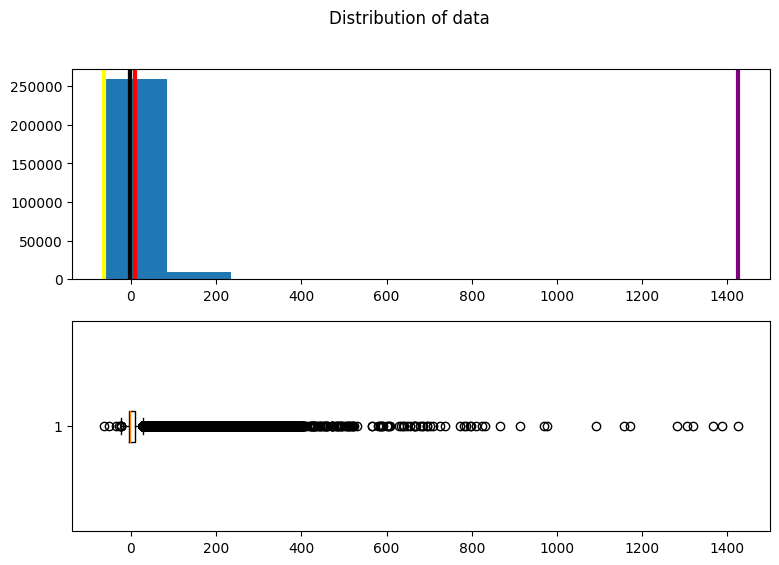

In [61]:
Dep_delay = data['DepDelay']
distribution(Dep_delay)

**Removing Outliers** - 
This data is quite uneven according to our histogram and it also has a good number of outliers according to our boxplot graph. So, let's start removing them.<br>
We'll use the `quantile` function of *pandas* library to remove our outliers.

Mean : 2.455424304018821
Median: -1.0
Mode: -3
Min: -7
Max: 37


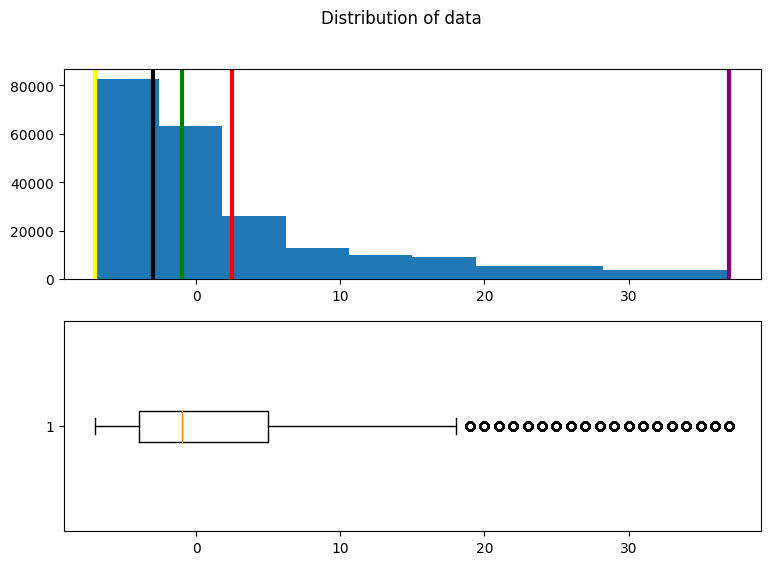

In [62]:
Dep_out = Dep_delay.quantile(0.9)
Dep_in = Dep_delay.quantile(0.1)
Dep_delay = Dep_delay[Dep_delay.between(Dep_in, Dep_out)]
distribution(Dep_delay)

**`Quantile`** function helps us to remove outliers present in our data. In the previous cell,On the line 1,I added the quantile function with a parameter of 0.9 which take the values above the 90% and assigns it to a variable **Dep_out**. On the 2nd line, I added the quantile function with the parameter of 0.1 which takes the values below 10% and assigns it to a variable **Dep_in**.

---

Now that the *DepDelay* column is clean, let's start cleaning *ArrDelay* column.

In [63]:
Arr_Delay = data['ArrDelay']
Arr_out = Arr_Delay.quantile(0.9)
Arr_in = Arr_Delay.quantile(0.1)
Arr_Delay = Arr_Delay[Arr_Delay.between(Arr_out,Arr_in)]

We have cleared ***Arr_Delay*** and ***Dep_Delay*** columns which are our labels on which we'll be building our models.

---

### Density Plot

Another way of visualizing data is by plotting its density. *Pandas* library has a useful and effective way to do this.

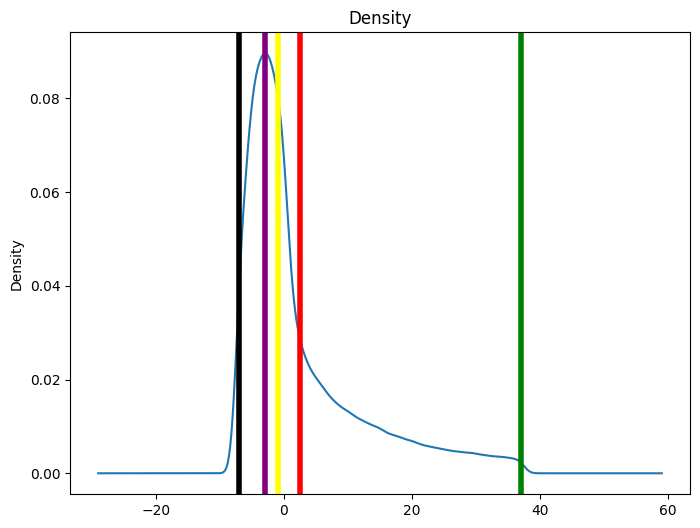

In [64]:
def density(var):
    import matplotlib.pyplot as mp
    fig = mp.figure(figsize=(8,6)) # Figure function is same as subplots but it creates only a single figure
    var.plot.density() # Plotting density
    mp.title("Density")
    mean = var.mean()
    median = var.median()
    mode = var.mode()[0]
    max = var.max()
    min = var.min()
    mp.axvline(x=mean,color='red',linewidth=4)
    mp.axvline(x=median,color='yellow',linewidth=4)
    mp.axvline(x=max,color='green',linewidth=4)
    mp.axvline(x=min,color='black',linewidth=4)
    mp.axvline(x=mode,color='purple',linewidth=4)
    mp.show()

density(Dep_delay)

### Standard Deviation and Variance

Variance is an important concept in statistical analysis of data. In python, there are pre-defined functions which help us calculate the standard and mean deviation of our data.

---

**Standard and Mean deviation** - What is the difference?
While they both tell the deviation of data from its mean, their calculation is a bit different.

*The **mean deviation** is calculated by subtracting mean from each value and taking average of the difference, while **standard deviation** is calculated by the root of **variance** which in turn is calculated by the squared difference between mean and values.*

Since *standard deviation* uses squared values, it is more sensitive to **outliers**.

---

**Calculating variance and standard deviation in *Python***

In [65]:
std = Dep_delay.std()
var = Dep_delay.var()
print("Standard deviation: {0}\nVariance: {1}\n".format(std,var))

Standard deviation: 9.55529988893759
Variance: 91.30375596753073



We can also use **`describe`** function. It is a more useful function as it provides all the useful information required to analyze our data.

In [66]:
data.describe(exclude=[object])
#exclude argument takes a list of types which should not be included while calculating mean,variance,etc.

,Year,Month,DayofMonth,DayOfWeek,OriginAirportID,DestAirportID,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
count,269179.0,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000
mean,2013.0,6.983877,15.817259,3.902336,12744.767642,12739.446093,1324.412933,10.456614,0.201134,1504.637338,6.563287,0.207888,0.000576
std,0.0,1.983873,8.805963,1.989296,1501.949045,1503.506863,470.760511,35.840715,0.400849,493.215438,38.420207,0.405797,0.023989
min,2013.0,4.000000,1.000000,1.000000,10140.000000,10140.000000,1.000000,-63.000000,0.000000,1.000000,-75.000000,0.000000,0.000000
25%,2013.0,5.000000,8.000000,2.000000,11292.000000,11292.000000,920.000000,-4.000000,0.000000,1119.000000,-11.000000,0.000000,0.000000
50%,2013.0,7.000000,16.000000,4.000000,12892.000000,12892.000000,1319.000000,-1.000000,0.000000,1527.000000,-3.000000,0.000000,0.000000
75%,2013.0,9.000000,23.000000,6.000000,14057.000000,14057.000000,1722.000000,9.000000,0.000000,1917.000000,10.000000,0.000000,0.000000
max,2013.0,10.000000,31.000000,7.000000,15376.000000,15376.000000,2359.000000,1425.000000,1.000000,2359.000000,1440.000000,1.000000,1.000000


With this, We Complete our Data Analysis part. But it is hard to maintain low ***MSE*** and ***RMSE*** without normalizing it. So, let's start normalizing our data.

---

### Normalizing Data

It is important to normalize data especially numeric values so that they are always measured on the same scale. This helps our model to easily find out *correlation* between them. For this, we are going to use **sklearn** Library.

Our columns of interest(*ArrDelay* and *DepDelay*) are already normalized, so we don't need to change it. So
we'll leave it as it is.

In [67]:
# from sklearn.preprocessing import MinMaxScaler

# Get a scaler object
# scaler = MinMaxScaler()

# Create a new dataframe for the scaled values
# df_normalized = df_sample[['Name', 'Grade', 'StudyHours']].copy()

# Normalize the numeric columns
# df_normalized[['Grade','StudyHours']] = scaler.fit_transform(df_normalized[['Grade','StudyHours']])

# Plot the normalized values
# df_normalized.plot(x='Name', y=['Grade','StudyHours'], kind='bar', figsize=(8,5))

### Finding Correlation

Let's find correlation betweeen our data by using **`corr()`** function.

In [68]:
data.DepDelay.corr(data.ArrDelay)

0.9388604387910373

Correlation is a statistic value that shows the *strength of relationship* between two data. its value is b/w 1 & -1. In our case, the **corr()** function returns a value of 0.94 (approx) which means that *DepDelay* and *ArrDelay* have a strong relationship.
> WARNING: data scientist often use quote - ***correlation is not the causation*** which means here that high correlation value does not indicate higher departure delays have high arrival delays or vice versa.

---

***Visualising Correlation***:<br>
we can use a scatter plot to demonstrate the correlation between our data.

<Axes: xlabel='DepDelay', ylabel='ArrDelay'>

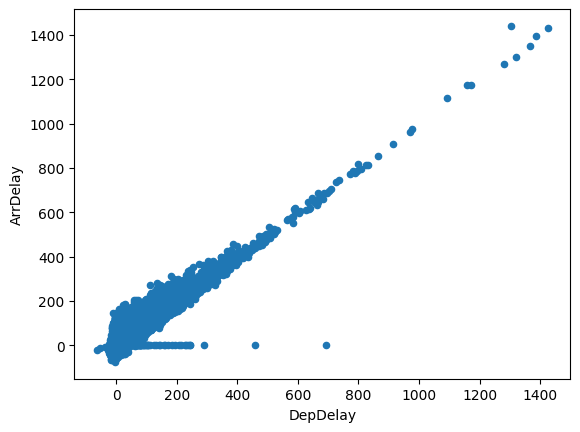

In [69]:
data.plot.scatter(x='DepDelay', y='ArrDelay')

## Regression

Till now whatever we've done is Data Analysis. But now, we take a step forward and start learning about traning and evaluating Regression models.
For that we'll move step by step.

1. [Find out what label is to be predicted](#find-out-which-label-is-to-be-predicted)
2. [Separate features into numeric and categorical features](#separate-features-into-numeric-and-categorical)
3. [Split training and testing data](#split-training-and-test-data)
4. [Train and Evaluate the model](#train-and-evaluate-the-model)
6. [Test model using different algorithms](#trying-different-algorithms)
7. [Optimizing Hyperparameters](#optimizing-hyperparameters)
8. [Preprocessing Data](#preprocessing-data)
9. [Using The Regression model](#using-the-regression-model)

The data we used till now is perfect for data analysis but is not suitable for Regression models, so we use a different data i.e. [Auto MPG](https://archive.ics.uci.edu/dataset/9/auto+mpg)

Since we have a new dataset, we'll need to analyze it first.

---

In [70]:
# Importing Data
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model year", "origin", "car name"]
dt = {'mpg': float, 'cylinders': int, 'displacement': float, 'weight': float, 'acceleration': float, 'model year': int, 'origin': int}
df = pd.read_csv(url, sep="\s+", names=columns, dtype=dt)
print(df.head())
print(df.describe())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0      130.0  3504.0          12.0          70   
1  15.0          8         350.0      165.0  3693.0          11.5          70   
2  18.0          8         318.0      150.0  3436.0          11.0          70   
3  16.0          8         304.0      150.0  3433.0          12.0          70   
4  17.0          8         302.0      140.0  3449.0          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774 

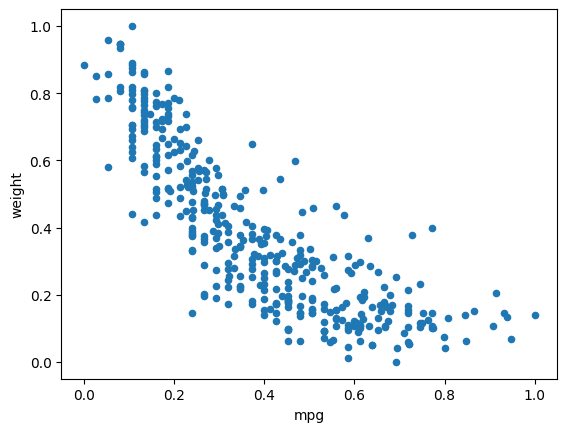

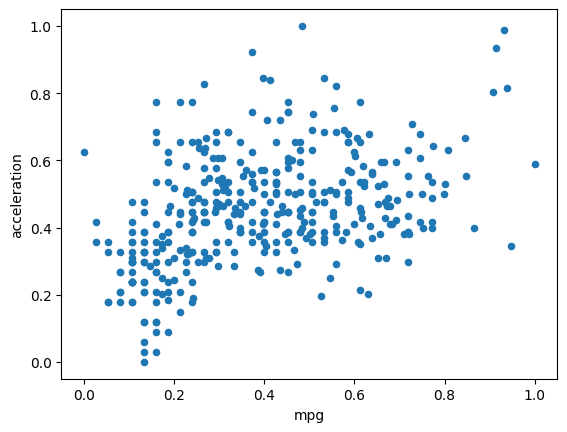

In [71]:
# It doesn't have any null value, so we'll skip this step
# distribution() shows that there is no outlier in the data, so that step is also skipped
# But we'll have to normalize our data, so...
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
df[['mpg','weight','acceleration']] = sc.fit_transform(df[['mpg','weight','acceleration']])
# Our data is also normalized, let's see its distribution over MPG
y=['weight', 'acceleration']
for i in y:
    df.plot.scatter(x='mpg',y=i)

Now, let's start creating and training a regression model.

---

### Find out which label is to be predicted

In the Auto-MPG data, it is already given that we have to train a model which predicts values for **MPG** column.

---

Let's see our label's distribution-

Mean : 0.38602587405110655
Median: 0.3723404255319148
Mode: 0.10638297872340427
Min: 0.0
Max: 1.0000000000000002


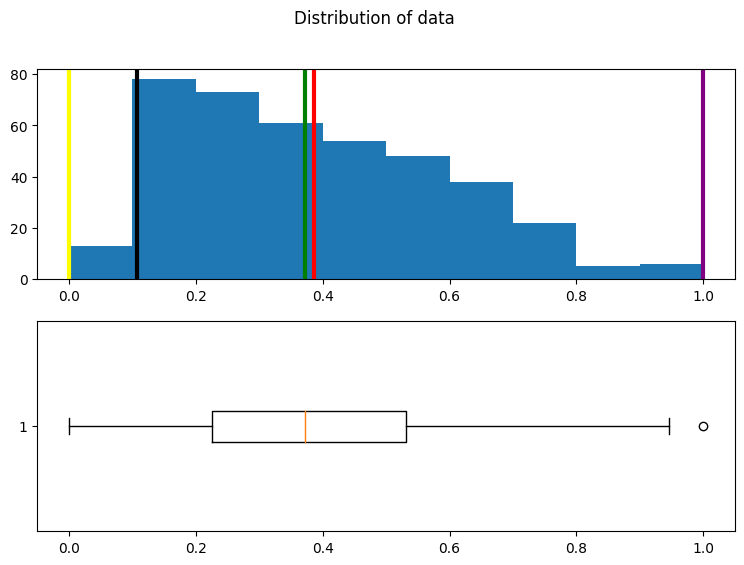

In [72]:
label = df['mpg']
distribution(label)

### Separate features into numeric and categorical

For this, first we have to make sure what columns are features, by looking into the columns, it is easy to note that *car name* column is useless. A simple way of determining which columns are numeric feature and which are categorical is to check their data type. 

In [73]:
df.dtypes

mpg             float64
cylinders         int32
displacement    float64
horsepower       object
weight          float64
acceleration    float64
model year        int32
origin            int32
car name         object
dtype: object

Usually, categorical features are of **object** dtype and numeric of **float** or **int**, but here, columns have a disrupted dtype. So, we'll classify them as per they should be.

In [74]:
cf = ['model year', 'origin','cylinders']
nf = ['displacement','weight','acceleration']

As we have separated out numeric and categorical features, let's see how they are distributed-

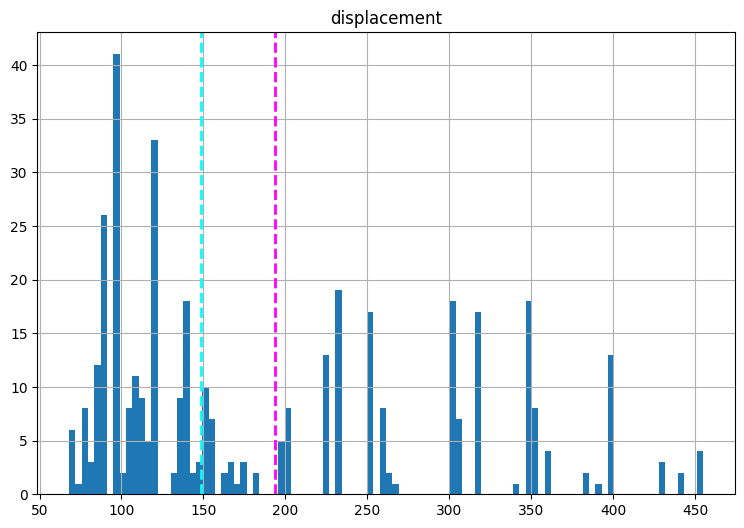

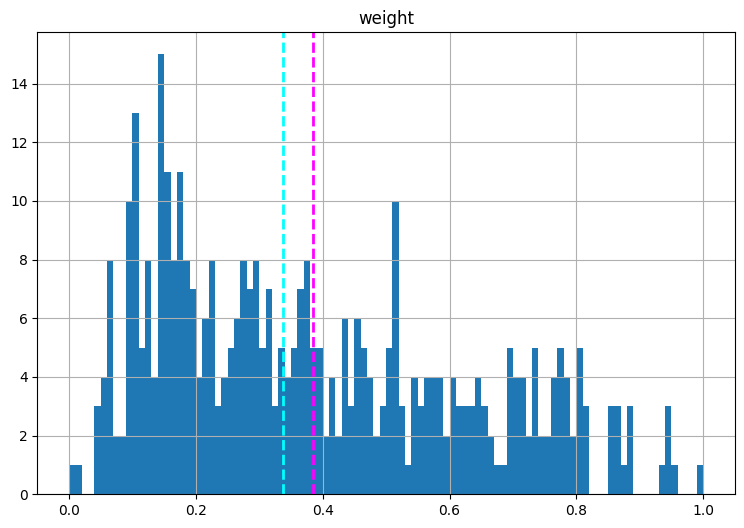

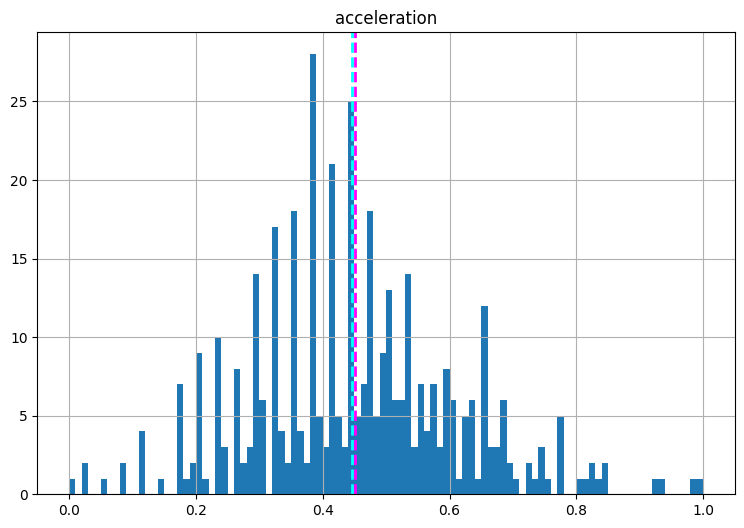

In [75]:
for col in nf:
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]
    feature.hist(bins=100, ax = ax)
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2)
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2)
    ax.set_title(col)
mp.show()

Now let's explore the distribution of categorical features-

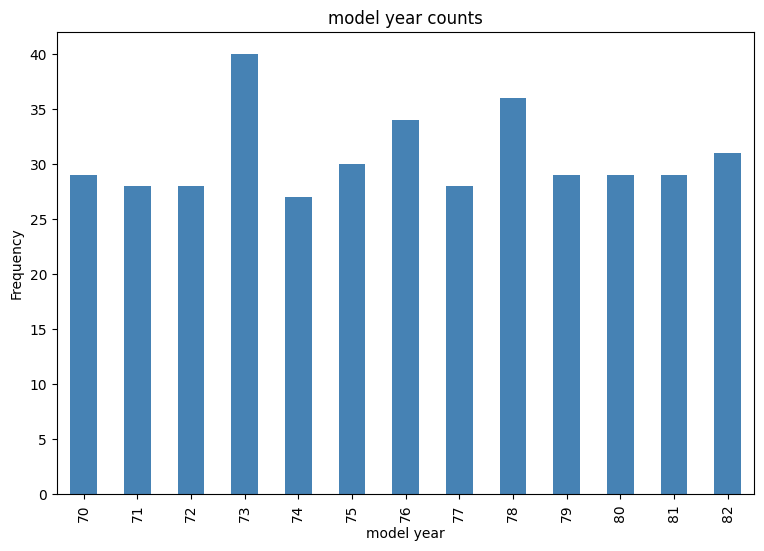

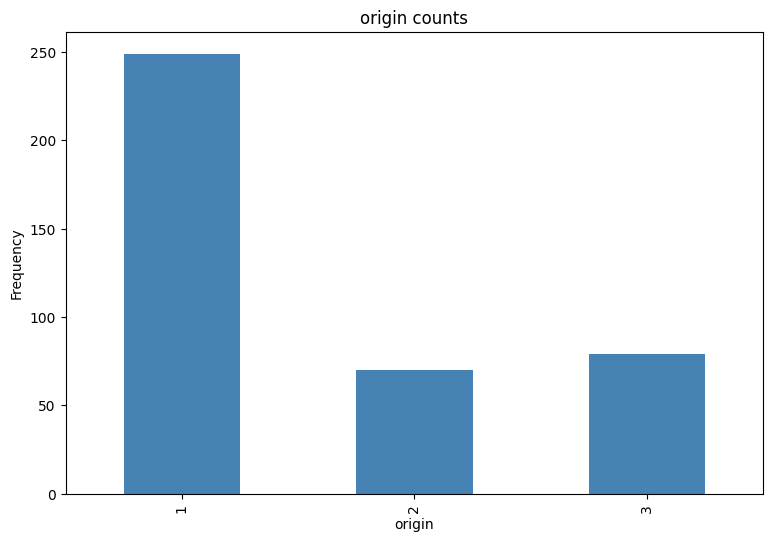

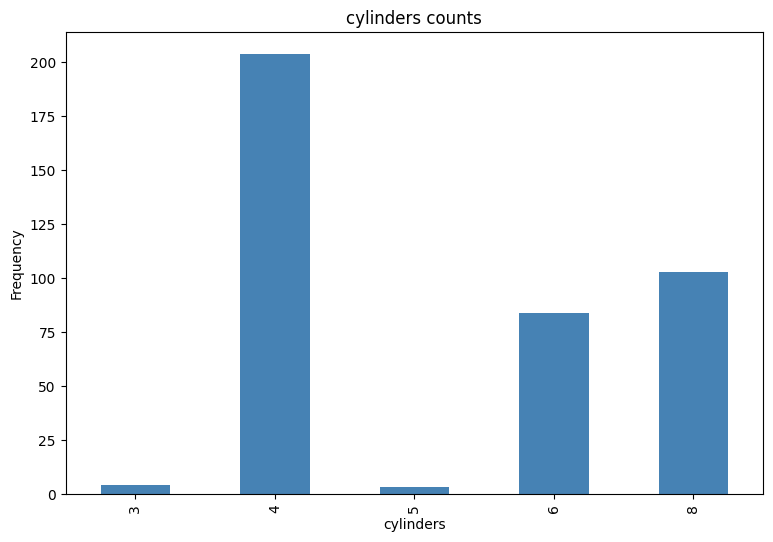

In [76]:
for col in cf:
    counts = df[col].value_counts().sort_index()
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    counts.plot.bar(ax = ax, color='steelblue')
    ax.set_title(col + ' counts')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
mp.show()


Checking features' relation with our label-

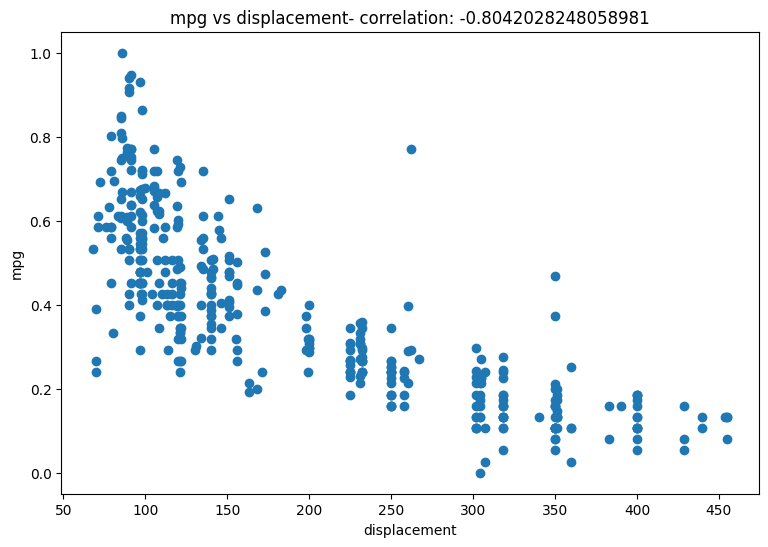

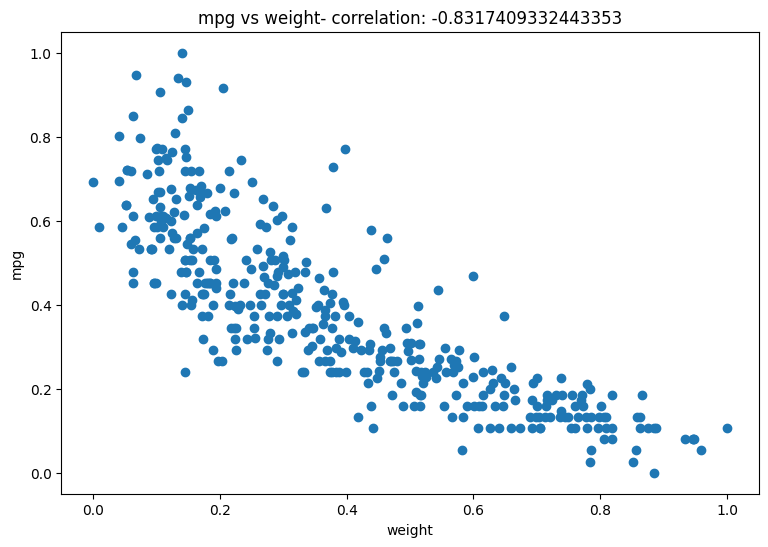

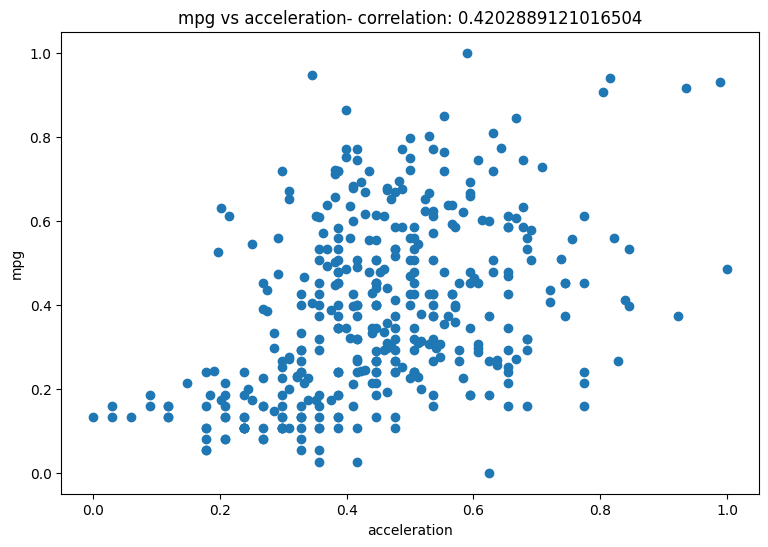

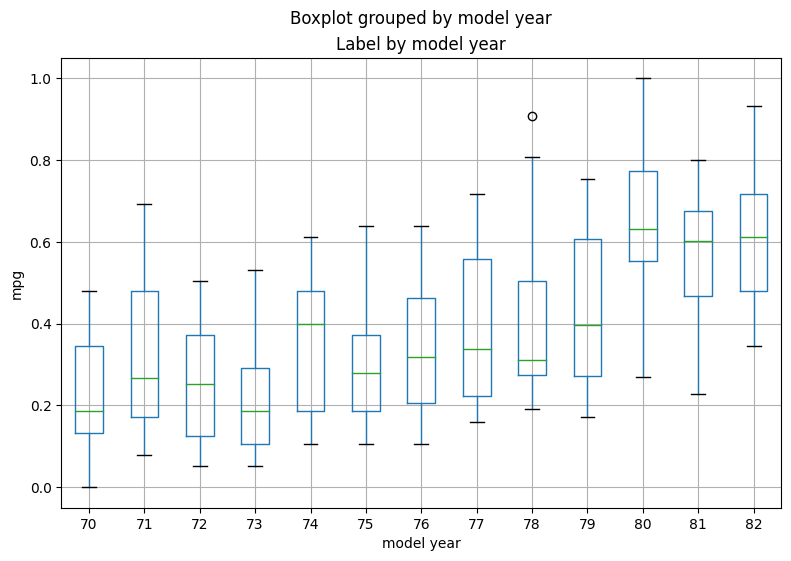

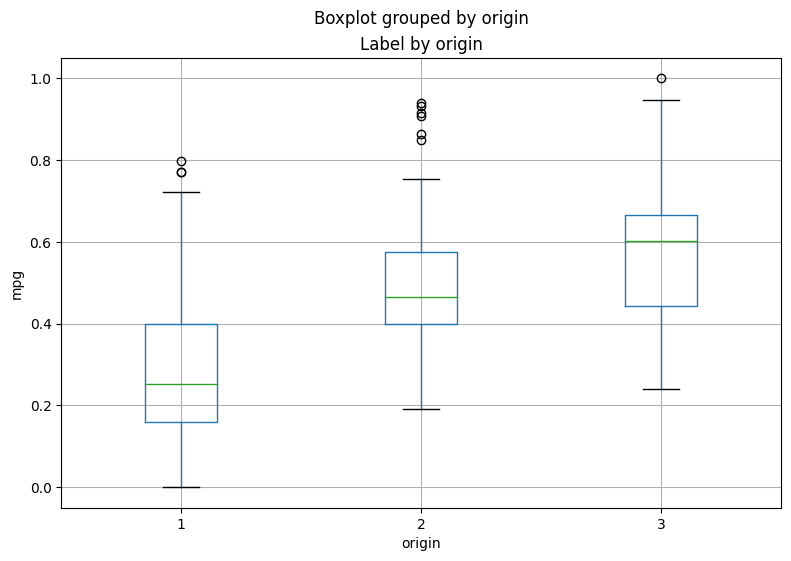

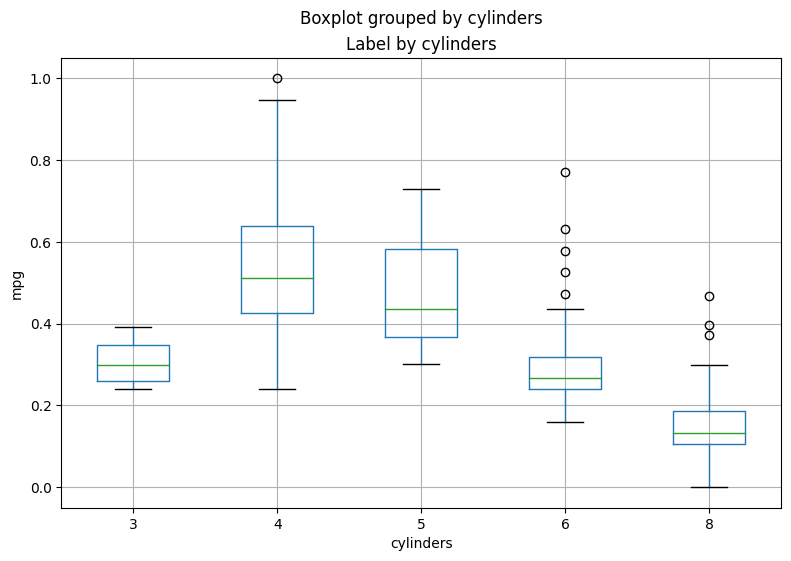

In [77]:
for col in nf:
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]
    label = df['mpg']
    correlation = feature.corr(label)
    mp.scatter(x=feature, y=label)
    mp.xlabel(col)
    mp.ylabel('mpg')
    ax.set_title('mpg vs ' + col + '- correlation: ' + str(correlation))
mp.show()
# plot a boxplot for the label by each categorical feature
for col in cf:
    fig = mp.figure(figsize=(9, 6))
    ax = fig.gca()
    df.boxplot(column = 'mpg', by = col, ax = ax)
    ax.set_title('Label by ' + col)
    ax.set_ylabel("mpg")
mp.show()

### Split Training and Test Data

Our data exploration is complete, now let's get back to action!
First, we need to separate out label and features-

In [78]:
x, y = df[['cylinders','acceleration','origin','model year','weight','displacement']].values, df['mpg'].values

Now let's split the data into two sets- Training set and Test set where training set will be bigger.

In [79]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20)

print ('Training Set: %d rows\nTest Set: %d rows' % (x_train.shape[0], x_test.shape[0]))

Training Set: 318 rows
Test Set: 80 rows


***test_size*** attribute determines what %age of data to be left as test data, *0.20* means that 20% of data will be set as test data.

---

### Train and Evaluate the model

We're all set to train our first LinearRegression model.

In [80]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x_train,y_train)
print(model)

LinearRegression()


#### Evaluation

Training of our regression model is complete, we can start evaluating it.

---

##### Testing the model

In [81]:
import numpy as np
predicted = model.predict(x_test)
np.set_printoptions(suppress=True)
print("Predictions: ", np.round(predicted)[ :10])
print("Reality: ", y_test[ :10])

Predictions:  [1. 0. 0. 0. 0. 0. 1. 0. 0. 1.]
Reality:  [0.58510638 0.24202128 0.31914894 0.25265957 0.29787234 0.29255319
 0.53191489 0.30851064 0.2393617  0.50531915]


It is veery tedious to look for every label if it is true or not, so we'll plot a graph for an overview of our model-

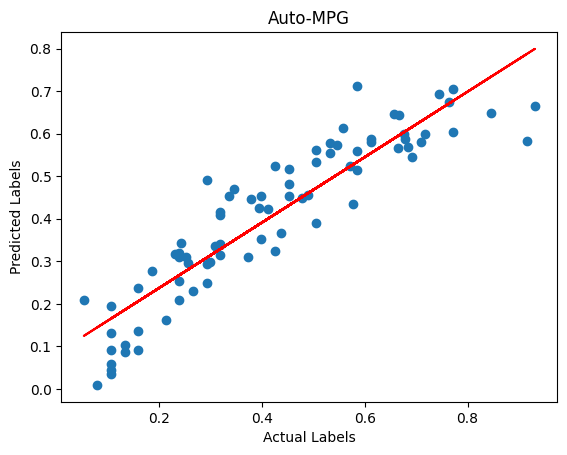

In [82]:
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

##### Finding RMSE, MSE and R2_Score

Testing of our model is complete, so we should check how good or bad our model performed. For this we'll use:-
1. **MSE**: the *mean-squared-error* shows a relative metric of our model. The smaller the value, the better the model.
2. **RMSE**: the *root-mean-squared-error* represents an average number of wrong predictions.
3. **R2_Score**: the *coefficient-of-determination* is a metric of how much variance the model is able to depict of our data.

In [83]:
from sklearn.metrics import mean_squared_error, r2_score
mse_1 = mean_squared_error(y_test,predicted)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_1,rmse_1,r2_1))

MSE:0.008342443548866523
RMSE:0.09133697799285087
R2:0.8247099539762528


### Trying different algorithms

Let's try these algorithms on our regression model - 

1. Linear Algorithms
2. Decision - Tree Algorithms
3. Ensemble Algorithms

Although only one algorithm is sufficient for a model, but in real world cases, it is hard to predict which algorithm is good for your model. So, we'll use evaluation of ***RMSE, MSE and R2_Score*** after each and every algorithm.

---

#### Linear Algorithms

Linear algorithms focus on finding collinearity between the dataset and using it to predict label values.

---

##### Lasso Algorithm

Lasso algorithm is useful when data has **sparse coefficients**(values that are close to zero), it reduces the dependency of data on its features.

Lasso()
MSE:0.01681351609513055
RMSE:0.129666942954365
R2:0.6467171767033548


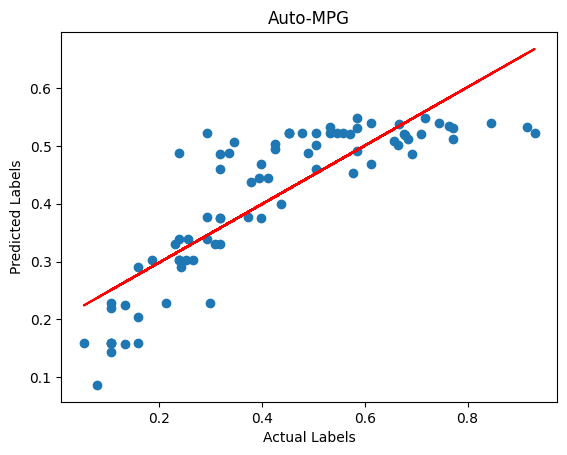

In [84]:
# Lasso Regression
from sklearn.linear_model import Lasso
model = Lasso().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_2 = mean_squared_error(y_test,predicted)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_2,rmse_2,r2_2))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

##### Ridge Algorithm

Ridge algorithm is useful when the data is multi-dimensional or data has a high number of features on which it depends.

Ridge()
MSE:0.00853878594782802
RMSE:0.09240555149896579
R2:0.8205844399168799


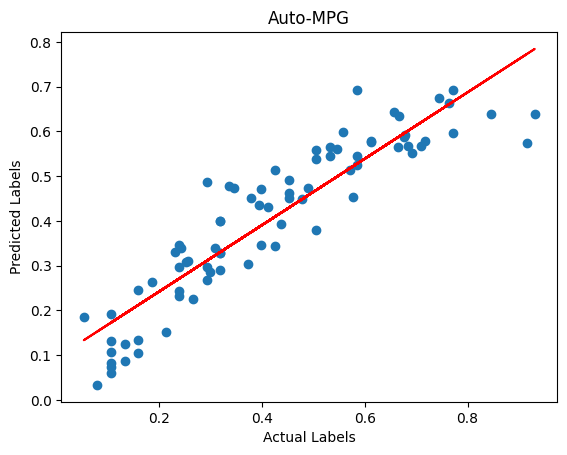

In [85]:
# Ridge Regression
from sklearn.linear_model import Ridge
model = Ridge().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_3 = mean_squared_error(y_test,predicted)
rmse_3 = np.sqrt(mse_3)
r2_3 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_3,rmse_3,r2_3))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

#### Decision-Tree Algorithm

In a tree-based algorithm, Each branch is a feature value determined by the series of evaluations of each feature in hte dataset. Each branch contains predicted label values based on branch values in the form of leaf nodes.

DecisionTreeRegressor()
MSE:0.0068100314056134025
RMSE:0.08252291442752978
R2:0.8569087448394748


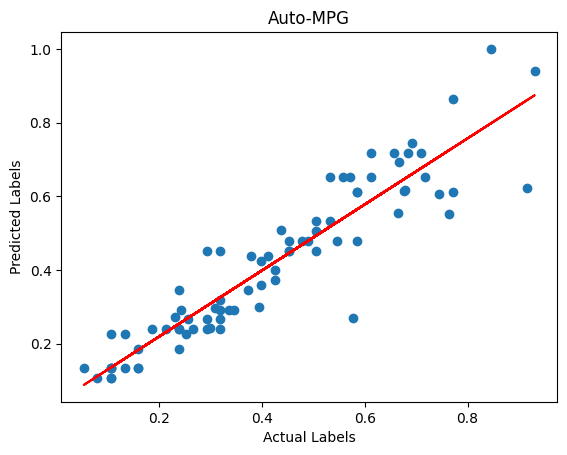

In [86]:
# Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_4 = mean_squared_error(y_test,predicted)
rmse_4 = np.sqrt(mse_4)
r2_4 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_4,rmse_4,r2_4))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

#### Ensemble Algorithm

Ensemble algorithms work by combining multiple base models to produce a main model with a reduced error. It has two types:

| Bagging | Boosting |
| :------: | :------: |
| Apply average function to the results of the collection of the base models. | Build a sequence of base models on top of previous one to improve the predictive performance. |

Let's use **RandomForestRegressor** for *bagging* and **GradientBoosting** for *boosting* :-

RandomForestRegressor()
MSE:0.003700098982500568
RMSE:0.06082843892868341
R2:0.9222541312823066


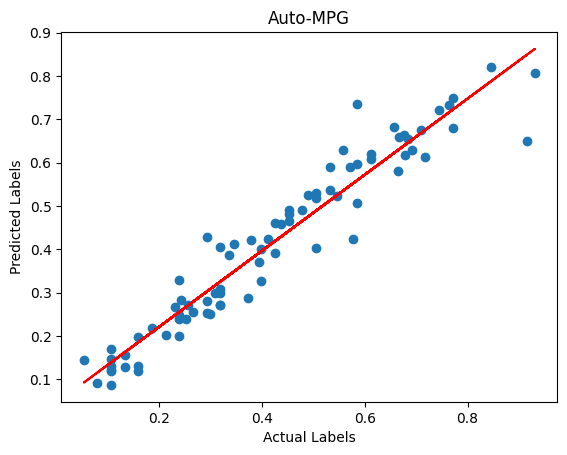

In [87]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_5 = mean_squared_error(y_test,predicted)
rmse_5 = np.sqrt(mse_5)
r2_5 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_5,rmse_5,r2_5))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

GradientBoostingRegressor()
MSE:0.004876723349379139
RMSE:0.06983354028959966
R2:0.8975310944149094


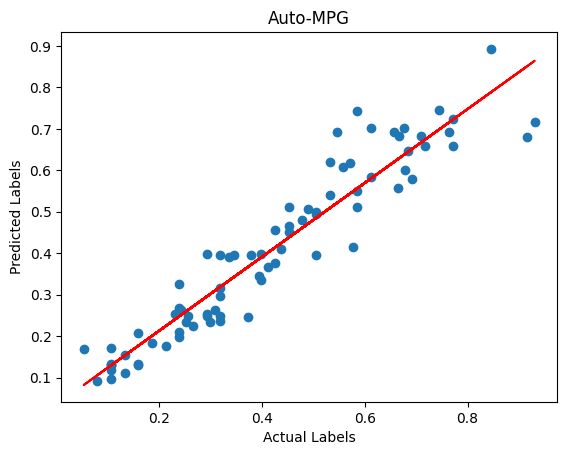

In [88]:
# Gradient Boosting Regression
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor().fit(x_train,y_train)
print(model)
predicted = model.predict(x_test)
# Model Evaluation
mse_6 = mean_squared_error(y_test,predicted)
rmse_6 = np.sqrt(mse_6)
r2_6 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_6,rmse_6,r2_6))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

By looking at the graph of **GradientBoosting** and **RandomForest**, we can see that it uses a number of parameters to train the model. What if we could change or provide the values of these parameters? 

---

### Optimizing Hyperparameters

A **Hyperparameter** is a value that you specify to change the behaviour of the regression model. They vary based upon the algorithm you use. Their optimization is important since they directly affect the performance and training time of the model.

Each algorithm has its specific type of hyperparameters and their tuning might result in a better predictive performance than that with default values. They can be viewed at [SKlearn documentation](https://scikit-learn.org/stable/user_guide.html).

Since we lack the **Deep Learning behind algorithms**, we'll have to experiment to correctly provide the values required to *tune* the hyperparameters.

**SKLearn** provides us a way of doing that by ***GridSearchCV***. It uses a grid of possible values and tries different combinations out of them.

> **Note:** There is a very less probablity that a *tuned* model will be significantly better than an *untuned* model.

Best parameters:  {'learning_rate': 0.01, 'n_estimators': 400}
Best Estimator  GradientBoostingRegressor(learning_rate=0.01, n_estimators=400)
MSE:0.004103078517554841
RMSE:0.06405527704689787
R2:0.9137867918472211


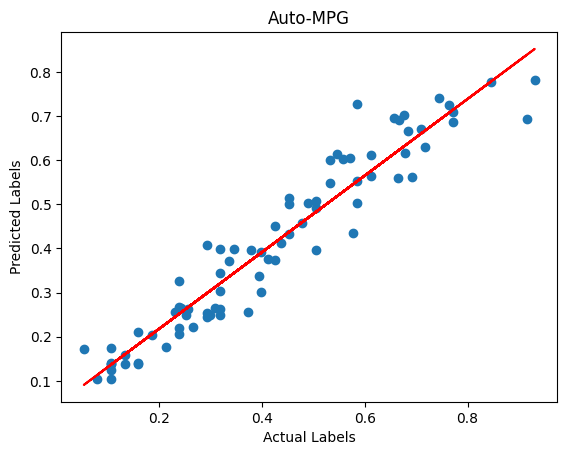

In [89]:
from sklearn.model_selection import GridSearchCV as gs
from sklearn.metrics import make_scorer as ms, r2_score as r2
alg = GradientBoostingRegressor()

parameters = {'learning_rate' : [0.01,0.05,0.1,0.5,1],
            'n_estimators' : [100,200,300,400,500]}
scorer = ms(r2)
grid_obj = gs(alg,parameters,scoring=scorer)
grid_obj.fit(x_train,y_train)
print("Best parameters: ",grid_obj.best_params_)

# best estimator
model = grid_obj.best_estimator_
print("Best Estimator ",model)
predicted = model.predict(x_test)
# Model Evaluation
mse_7 = mean_squared_error(y_test,predicted)
rmse_7 = np.sqrt(mse_7)
r2_7 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_7,rmse_7,r2_7))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

### Preprocessing Data

Our model is trained from data directly taken from the internet. But, in reality some preprocessing is always done before incorporating data into the model. We did some normalization of data above, but that was only for numeric data types. In preprocessing, we also encode categorical features into numeric datatypes, like:

| Size |
| :------: |
| S |
| M |
| L |

encoded to:

| Size |
| :------: |
| 0 |
| 1 |
| 2 |

In preprocessing, we also convert all numeric features to a same scale just as we did while normalizing it.

There is one other common technique used in preprocessing called ***One Hot Encoding*** in which individual binary is created for different columns.

| Size_S | Size_M | Size_L |
| :------: | :------: | :------: |
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

These preprocessing transformations can be applied using ***Pipelines*** feature of sklearn library. Pipelines enable us to define preprocessing steps from start and end with an algorithm.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [2, 4, 5]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [1, 3, 4])])),
                ('regressor', GradientBoostingRegressor())])


MSE:0.006250809093924996
RMSE:0.07906205849789769
R2:0.868659031692382


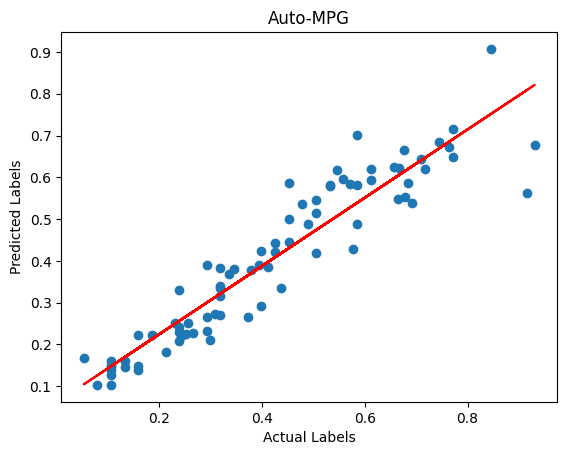

In [90]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Define preprocessing for numeric columns (scale them)
numeric_features = [2,4,5]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# Define preprocessing for categorical features (encode them)
categorical_features = [1,3,4]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', GradientBoostingRegressor())]) # We used GradientBoostingRegressor here, you can use any other regressor

# fit the pipeline to train a linear regression model on the training set
model = pipeline.fit(x_train, y_train)
print (model)

# Evaluate the predictions on the test set
predicted = model.predict(x_test)
mse_8 = mean_squared_error(y_test,predicted)
rmse_8 = np.sqrt(mse_8)
r2_8 = r2_score(y_test,predicted)
print("MSE:{0}\nRMSE:{1}\nR2:{2}".format(mse_8,rmse_8,r2_8))
# Graph of predicted vs actual
mp.scatter(y_test, predicted)
mp.xlabel('Actual Labels')
mp.ylabel('Predicted Labels')
mp.title('Auto-MPG')
# overlay the regression line
z = np.polyfit(y_test, predicted, 1)
p = np.poly1d(z)
mp.plot(y_test,p(y_test), color='red')
mp.show()

We've used a number of algorithms on training a regression model. Let's see how each one performed:

| Algorithm | Mean Squared Error | Root Mean Squared Error | R2 Score |
| :------: | :------: | :------: | :------: |
| Ordinary Least Squares | 0.007908528269411562 | 0.0889299064961364 | 0.7993072996343927 |
| Lasso | 0.013222000841184389 | 0.11498695943968772 | 0.6644686643762778 |
| Ridge | 0.007637075560757239 | 0.08739036308859942 | 0.806195885634914 |
| Decision - Tree | 0.005105445761656858 | 0.07145240207058723 | 0.8704404079277196 |
| RandomForestRegressor | 0.003331915715892369 | 0.05772274868621875 | 0.915446826560715 |
| GradientBoosting | 0.003939943212493586 | 0.06276896695416921 | 0.900017068199553 |
| Tuned GradientBoosting | 0.0037395866203007305 | 0.061152159571847754 | 0.9051014662257646 |
| Preprocessed GradientBoosting | 0.0049278717360855 | 0.07019880152884023 | 0.874946658584311 |

### Using the Regression model

Let's now learn how to save and use this model.

---

#### Saving the model

We'll use **JOBLIB** library to save the model we just created.

In [91]:
import joblib as jb
jb.dump(model,'d:/Projects/ML/assets/autompg-model.pkl')

['d:/Projects/ML/assets/autompg-model.pkl']

#### Using Model

We can use our model wherever we require it.

In [92]:
load = jb.load('d:/Projects/ML/assets/autompg-model.pkl')

# Testing custom data
import numpy as np

# Define some data to score
x_new = np.array([[8,307,130,3504,12,70]])
print ('New sample: {}'.format(x_new))
res = load.predict(x_new)
print('Predicted MPG: {}'.format(res[0]))

New sample: [[   8  307  130 3504   12   70]]
Predicted MPG: 0.24023028188165868


🎉Woohoo!🎉 You've completed Training a Regression Model. 

---

## Classification

Now that we've trained a regression model, let's learn how to train a classification model.
We'll train two types of classification model - 

1. **Binary Classification**: Classifies into either of two species.
2. **Multi - Classs Classification**: Classifies into more than two species.

---

### Binary Classification

For binary claqssification, we separate data into either 0 or 1 species. Let's import [Rice Species Dataset](https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik) for this purpose.

We'll follow these steps to train our model:

1. [Data Exploration](#data-exploration)
2. [Splitting Data](#splitting-data)
3. Training & Evaluation
4. Preprocessing
5. Trying different algorithms
6. Inferencing

---

#### Data Exploration

Let's import and see how our data is distributed.

In [93]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
# fetch dataset
rice_cammeo_and_osmancik = fetch_ucirepo(id=545)

# data (as pandas dataframes)
x = pd.DataFrame(rice_cammeo_and_osmancik.data.features)
y = pd.DataFrame(rice_cammeo_and_osmancik.data.targets)

# Description
print(x.describe())
print(y.describe())

               Area    Perimeter  Major_Axis_Length  Minor_Axis_Length  \
count   3810.000000  3810.000000        3810.000000        3810.000000   
mean   12667.727559   454.239180         188.776222          86.313750   
std     1732.367706    35.597081          17.448679           5.729817   
min     7551.000000   359.100006         145.264465          59.532406   
25%    11370.500000   426.144752         174.353855          82.731695   
50%    12421.500000   448.852493         185.810059          86.434647   
75%    13950.000000   483.683746         203.550438          90.143677   
max    18913.000000   548.445984         239.010498         107.542450   

       Eccentricity   Convex_Area       Extent  
count   3810.000000   3810.000000  3810.000000  
mean       0.886871  12952.496850     0.661934  
std        0.020818   1776.972042     0.077239  
min        0.777233   7723.000000     0.497413  
25%        0.872402  11626.250000     0.598862  
50%        0.889050  12706.500000     0

We have sucessfully imported our data and separated it. Let's start by seeing distributions of our data.

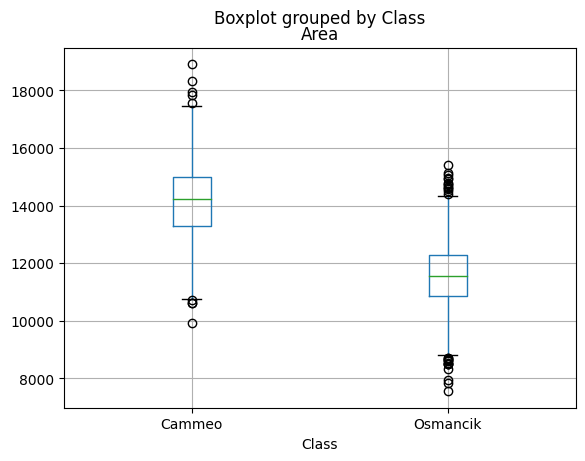

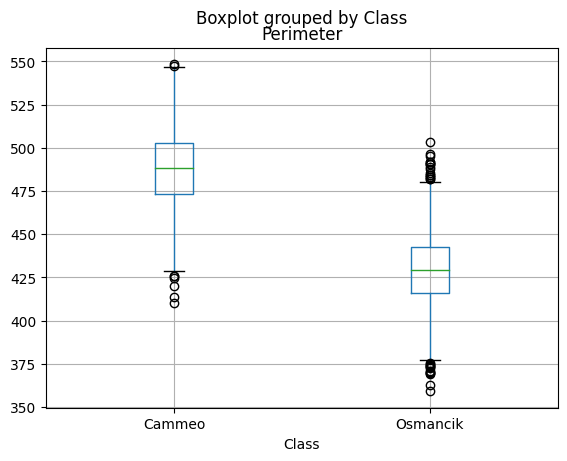

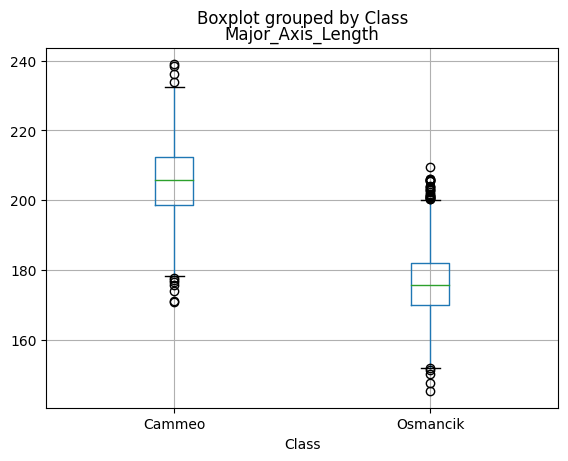

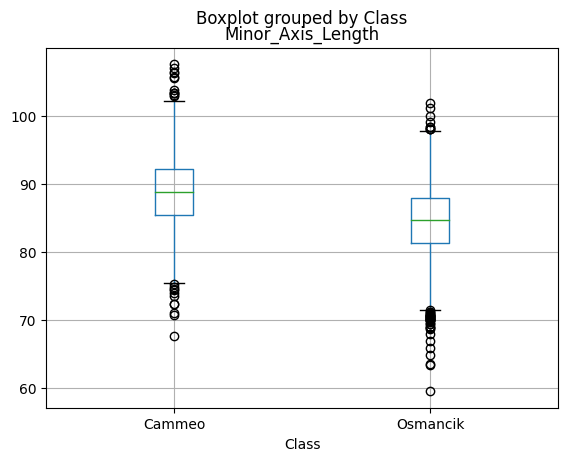

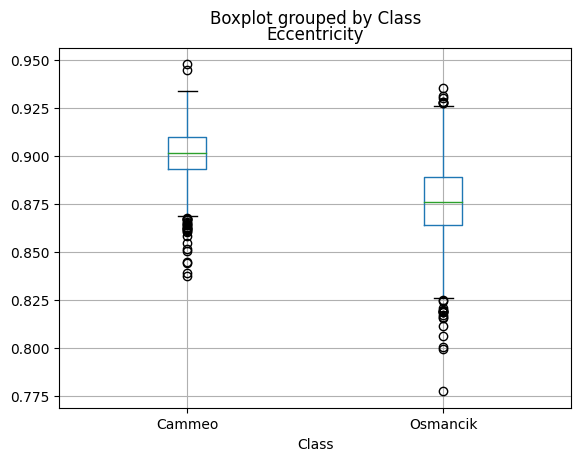

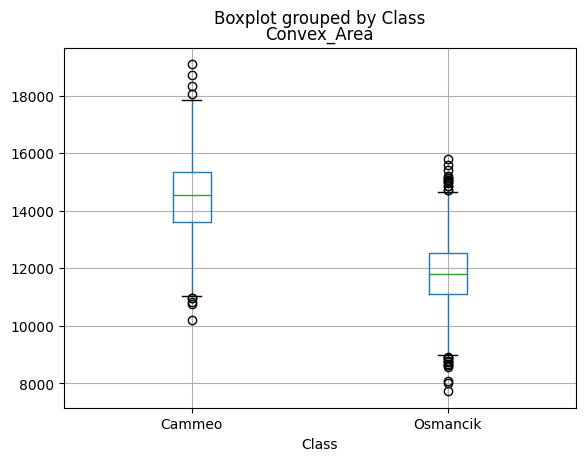

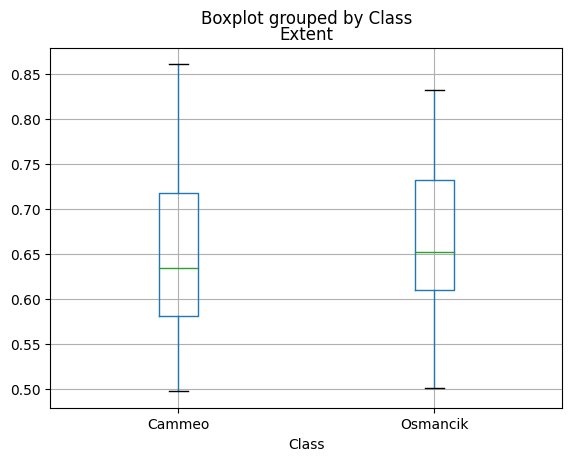

In [94]:
import matplotlib.pyplot as mp

df = pd.concat([x,y],axis=1)
classes = ['Cammeo', 'Osmancik']
features = x.columns
label = y.columns
for col in features:
    df.boxplot(column = col, by = 'Class')

There is a considerable difference between both the species in all the features except eccentricity.

#### Splitting Data

We'll split our data into test and training set in 1:4 ratio.

In [95]:
from sklearn.model_selection import train_test_split

# Converting target to 0 and 1
x = x.replace('Cammeo',0)
x = x.replace('Osmancik',1)
y = y.replace('Cammeo',0)
y = y.replace('Osmancik',1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25)

print ('Training Set: %d rows\nTest Set: %d rows' % (x_train.shape[0], x_test.shape[0]))

Training Set: 2857 rows
Test Set: 953 rows


#### Training and Evaluating model

Let's start Training our classification model by ***Logistic Regression***.

In [96]:
from sklearn.linear_model import LogisticRegression
# regularization parameter
reg = 0.01
# train a logistic regression model on the training set with the specified regularization parameter
model = LogisticRegression(C=1/reg, solver='liblinear').fit(x_train,y_train.values.ravel())
print(model)

LogisticRegression(C=100.0, solver='liblinear')


**Regularization parameter** is a numerical value that helps in counteracting any bias present in sample preventing overfitting of our model.

`ravel()` function converts a dataframe into a 1D-array.

---

##### Evaluation

Let's see how well our model performs.

In [97]:
res = model.predict(x_test)
print("Predicted Labels: {0}\nActual Labels: {1}".format(res[:10], y_test[:10]))

Predicted Labels: [1 1 1 1 1 1 1 0 0 0]
Actual Labels:       Class
2432      1
3279      1
1722      1
3362      1
2922      1
2831      1
2413      1
109       0
992       0
495       0


For evaluation, we have different metrics like accuracy, precision-score, etc. Let's use them one by one on our model.

In [98]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test,res)
print("Accuracy: ",acc*100 ,"%")

Accuracy:  92.96956977964324 %


Our model has good accuracy but we can't depend only on accuracy score of our model. Let's have a look on *classification report* of our model.

In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test,res))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       426
           1       0.94      0.94      0.94       527

    accuracy                           0.93       953
   macro avg       0.93      0.93      0.93       953
weighted avg       0.93      0.93      0.93       953



The classification report includes the following:

1. *Precision*: Of the predictions made, what proportion was correct?
2. *Recall*: Out of all instances, what proportion did the model identify?
3. *F1-Score*: Average metric taking both Precision and recall into account.
4. *Support*: How many instances of this class are there.

---

The precision and recall can be derived from 4 possible outcomes-

1. *True Positives*: Both predicted and actual label is 1.
2. *True Negatives*: Both predicted and actual label is 0.
3. *False Positives*: Predicted label : 1, Actual label : 0
4. *False Negatives*: Predicted label : 0, Actual label : 1

These metrics can be collectively measured in a ***confusion matrix*** which is in format - 

<table style="border: 1px solid black;">
    <tr style="border: 1px solid black;">
        <td style="border: 1px solid black;color: black;" bgcolor="lightgray">TN</td><td style="border: 1px solid black;color: black;" bgcolor="white">FP</td>
    </tr>
    <tr style="border: 1px solid black;">
        <td style="border: 1px solid black;color: black;" bgcolor="white">FN</td><td style="border: 1px solid black;color: black;" bgcolor="lightgray">TP</td>
    </tr>
</table>


In [100]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,res)
print(cm)

[[392  34]
 [ 33 494]]


We can also see the probability with which our Logistic Regression algorithm predicted our labels by using **`predict_proba()`** function.

In [101]:
prob = model.predict_proba(x_test)
print(prob[:10])

[[0.03418202 0.96581798]
 [0.14202405 0.85797595]
 [0.25575479 0.74424521]
 [0.05403336 0.94596664]
 [0.01753106 0.98246894]
 [0.00728259 0.99271741]
 [0.03010909 0.96989091]
 [0.93779335 0.06220665]
 [0.99221758 0.00778242]
 [0.84528185 0.15471815]]


Let's plot a ***received operator characteristic(ROC)*** curve to see the performance of our model.

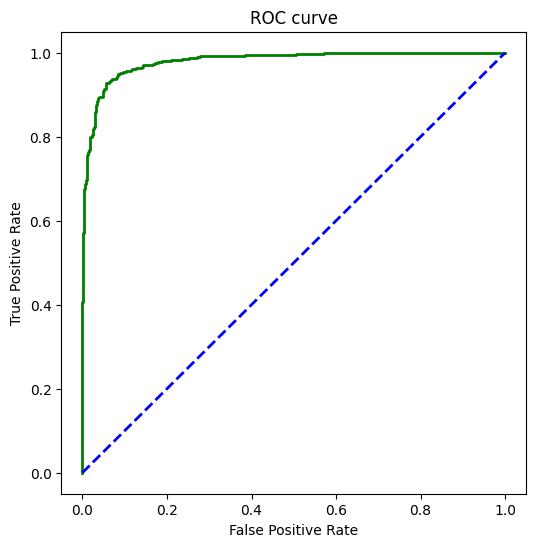

In [102]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as mp

fpr, tpr, thresholds = roc_curve(y_test, prob[:,1])
fig = mp.figure(figsize=(6, 6))
# Plot the diagonal 50% line
mp.plot(fpr, tpr, color='green', linestyle='-', linewidth=2)
mp.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC curve')
mp.show()

The ROC curve explanation as given by [Microsoft Learn Repo](https://github.com/MicrosoftDocs/ml-basics/) is-
>The ROC chart shows the curve of the true and false positive rates for different threshold values between 0 and 1. A perfect classifier would have a curve that goes straight up the left side and straight across the top. The diagonal line across the chart represents the probability of predicting correctly with a 50/50 random prediction; so you obviously want the curve to be higher than that (or your model is no better than simply guessing!).

According to this explanation, our ROC chart is pretty good. But we can't make conclusions just by looking at the graph, so, it is a good practice to calculate the **Area Under Curve** *(AUC)* metric for graphs we just plot.

In [103]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, prob[:,1])
print('AUC: %.2f' % auc)

AUC: 0.98


**Preprocessing our data**-

We can preprocess our data before feeding it into our model to improve performance of our model.

However, our model is already in a good position, so we'll create another model for preprocessed data.

In [104]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
import numpy as np

# Define preprocessing for numeric columns (scale them)
numeric_features = [0,1,2,3,4,5]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# Define preprocessing for categorical features (encode them)
categorical_features = [6]
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', LogisticRegression(C=1/reg, solver='liblinear'))]) # We used LogisticRegression here, you can use any other regressor

# fit the pipeline to train a linear regression model on the training set
model_pre = pipeline.fit(x_train, y_train.values.ravel())
print (model_pre)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [6])])),
                ('regressor', LogisticRegression(C=100.0, solver='liblinear'))])


Let's evaluate our preprocessed model-

Accuracy:  93.59916054564533 %
[[396  30]
 [ 31 496]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       426
           1       0.94      0.94      0.94       527

    accuracy                           0.94       953
   macro avg       0.94      0.94      0.94       953
weighted avg       0.94      0.94      0.94       953

AUC: 0.98


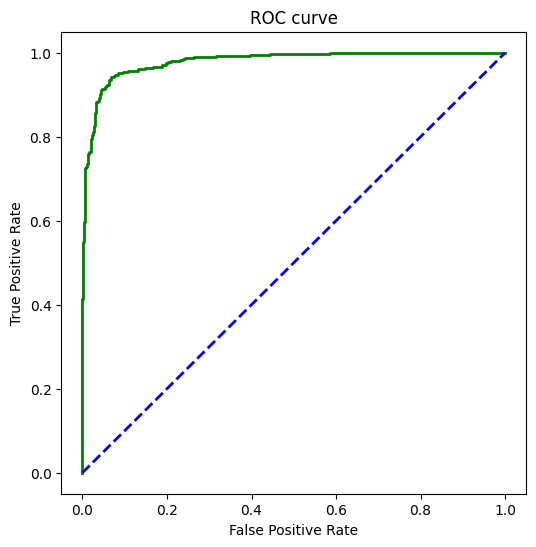

In [105]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as mp
# Evaluate the predictions on the test set
res = model_pre.predict(x_test)
acc = accuracy_score(y_test,res)
print("Accuracy: ",acc*100 ,"%")

# Confusion Matrix
cm = confusion_matrix(y_test,res)
print(cm)

# Classification Report
print(classification_report(y_test,res))

# AUC
auc = roc_auc_score(y_test, prob[:,1])
print('AUC: %.2f' % auc)

# ROC Curve
prob = model_pre.predict_proba(x_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:,1])
fig = mp.figure(figsize=(6, 6))
# Plot the diagonal 50% line
mp.plot(fpr, tpr, color='green', linestyle='-', linewidth=2)
mp.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC curve')
mp.show()

#### Trying different algorithm

Let's use ***Random Forest Classifier*** for our model and then we'll compare all the algorithms.

Accuracy:  92.75970619097586 %
[[390  36]
 [ 33 494]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       426
           1       0.93      0.94      0.93       527

    accuracy                           0.93       953
   macro avg       0.93      0.93      0.93       953
weighted avg       0.93      0.93      0.93       953

AUC: 0.97


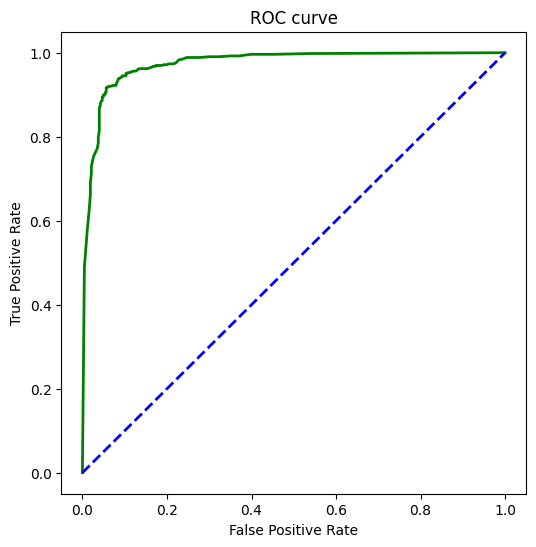

In [106]:
from sklearn.ensemble import RandomForestClassifier
# regularization parameter
reg = 0.01

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', RandomForestClassifier())]) # We used RandomForestClassifier here, you can use any other regressor

# fit the pipeline to train a linear regression model on the training set
model_rfc = pipeline.fit(x_train, y_train.values.ravel())

# Evaluate the predictions on the test set
res = model_rfc.predict(x_test)
acc = accuracy_score(y_test,res)
print("Accuracy: ",acc*100 ,"%")

# Confusion Matrix
cm = confusion_matrix(y_test,res)
print(cm)

# Classification Report
print(classification_report(y_test,res))

# AUC
prob = model_rfc.predict_proba(x_test)
auc = roc_auc_score(y_test, prob[:,1])
print('AUC: %.2f' % auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, prob[:,1])
fig = mp.figure(figsize=(6, 6))
# Plot the diagonal 50% line
mp.plot(fpr, tpr, color='green', linestyle='-', linewidth=2)
mp.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive Rate')
mp.title('ROC curve')
mp.show()

Let's compare all the different algorithms we used in our model-

| Algorithm | Accuracy | AUC |
| :------: | :------: | :------: |
| Logistic Regression | 93.6% | 0.98 |
| Preprocessed Logisitc Regression | 93.5% | 0.97 |
| Random Forest Classifier | 93.7% | 0.97 |

---

>**Note:** Reader should not consider Logistic Regression to be better just because of the table above, there are several algorithms for classification which act in different ways and perform well on different types of data. There are several reasons for other two not performing well but what I think it is because we used **One Hot Encoding** in our preprocessing pipeline which might not be compatible with the *LogisticRegression* and *RandomForestClassifier* algorithms.

#### Saving and using the model

We have a good model for classification, let's use it.

In [107]:
import joblib as jb

jb.dump(model,'d:/Projects/ML/assets/rice-model.pkl')

load = jb.load('d:/Projects/ML/assets/rice-model.pkl')

# Testing custom data
import numpy as np

# Define some data to score
x_new = np.array([[15.26,14.84,0.871,5.763,3.312,2.221,5.22]])
print ('New sample: {}'.format(x_new))
res = load.predict(x_new)
print('Predicted Class: {}'.format(res[0]))

New sample: [[15.26  14.84   0.871  5.763  3.312  2.221  5.22 ]]
Predicted Class: 1


C:\Users\chitr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Multi - Class Classification

We just saw how we can define a binary classification, but what if there are more than two classes to predict?

That's when multi-class classifiers come into play. They can be thought as multiple binary classifiers. They are of two types:

1. **One vs Rest(OVR)**: A classifier is created for each class with positive meaning prediction is *this* class and negative meaning prediction is any other class.
2. **One vs One(OVO)**: A classifier is created for all possible combinations.

Both combine all the classifiers' predictions into a vector and their prediction probabilities are used to determine class to predict.

---

For this type of classification, we'll use [Dry Bean Dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset) from UCI.

In [108]:
import pandas as pd
import matplotlib.pyplot as mp
# fetch dataset
bean = pd.read_excel('d:/Projects/ML/assets/bean.xlsx')
x = bean[['Area','Perimeter','MajorAxisLength','MinorAxisLength','AspectRatio','Eccentricity','ConvexArea','EquivDiameter','Extent','Solidity','roundness','Compactness','ShapeFactor1','ShapeFactor2','ShapeFactor3','ShapeFactor4']]
y = bean['Class']
y = y.replace('SEKER',0)
y = y.replace('BARBUNYA',1)
y = y.replace('BOMBAY',2)
y = y.replace('CALI',3)
y = y.replace('HOROZ',4)
y = y.replace('SIRA',5)
y = y.replace('DERMASON',6)
bean.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


#### Data Exploration

Let's start by exploring our data.

In [109]:
# Checking null values
print(x.isnull().sum())

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
dtype: int64


Since there are no null values, this dataset needs no further exploration, we can directly jump to relation of data with its targets-

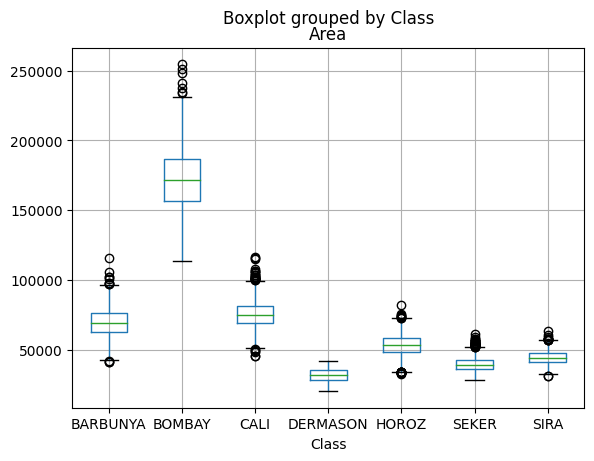

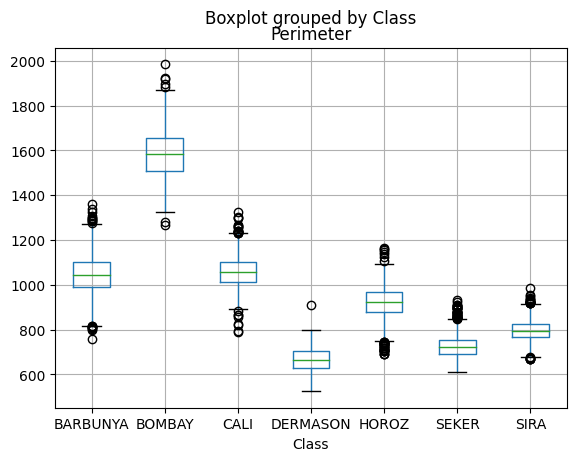

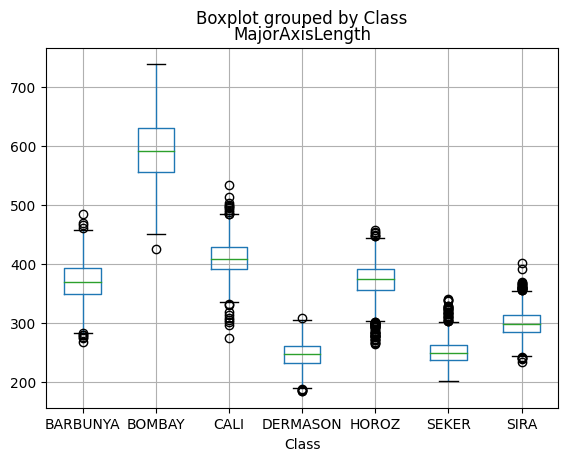

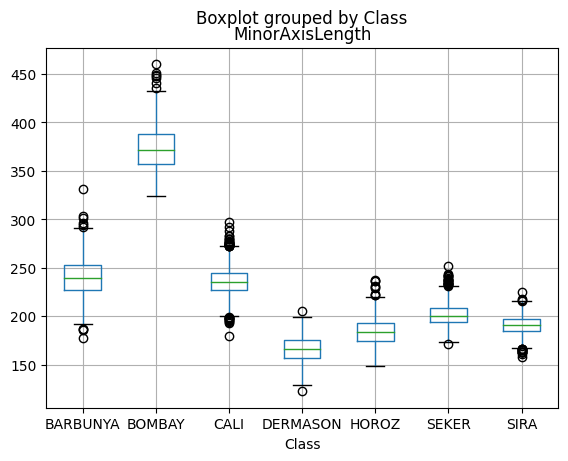

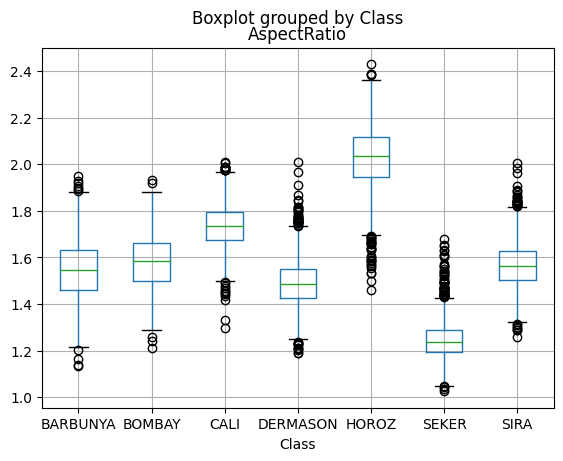

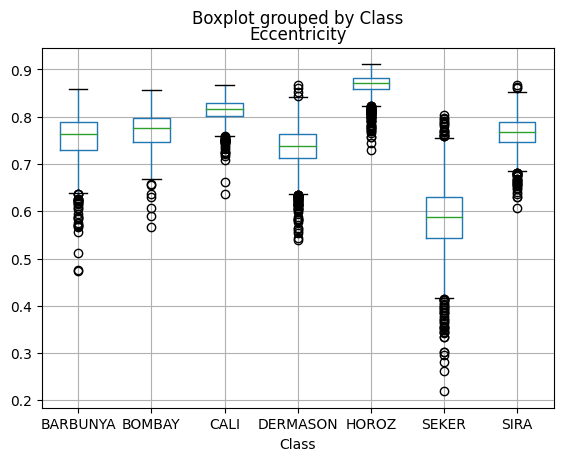

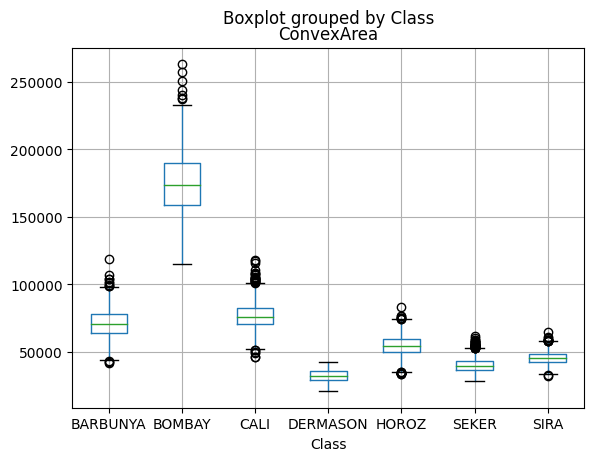

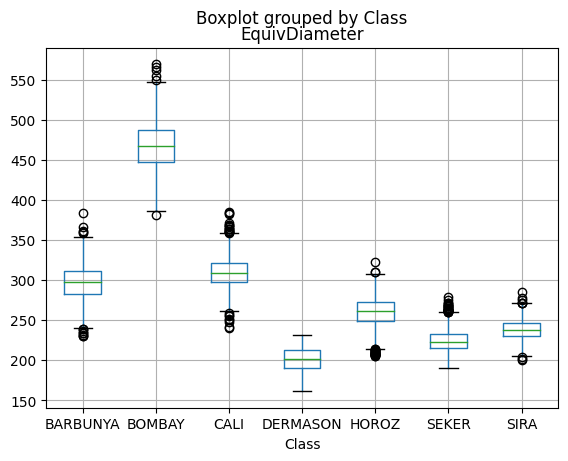

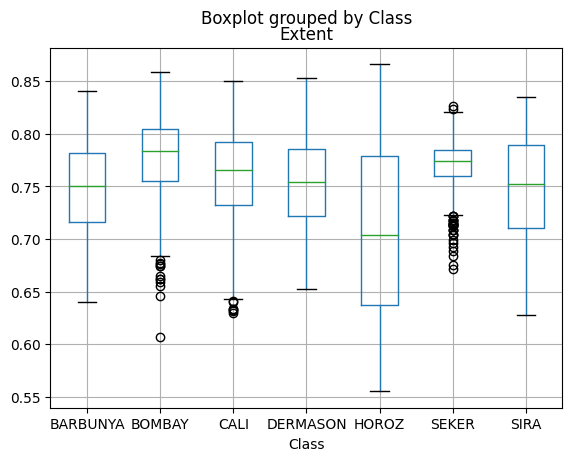

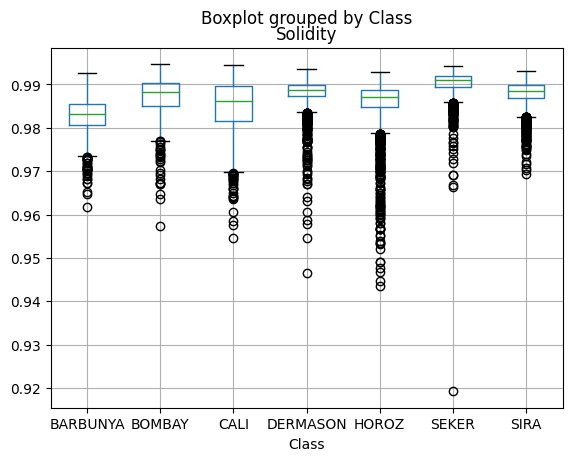

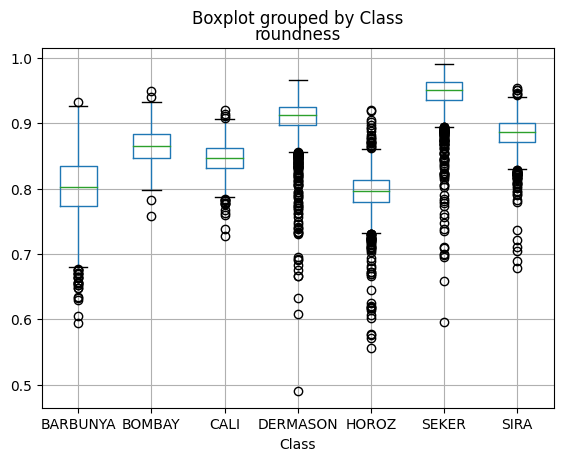

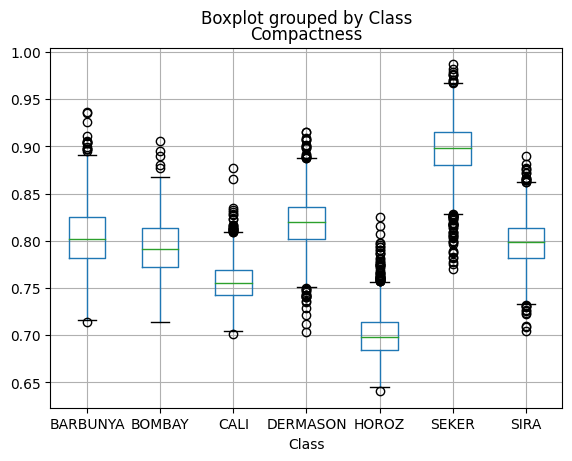

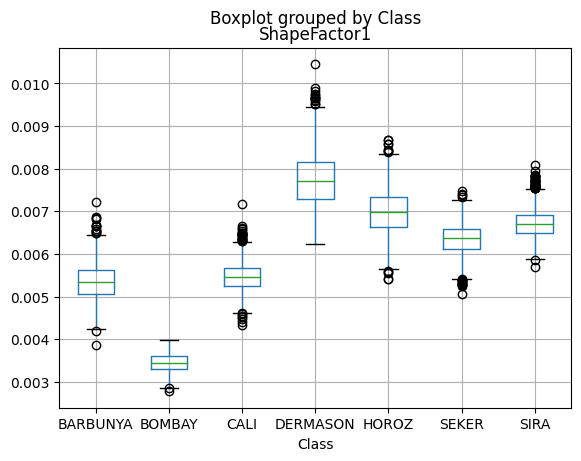

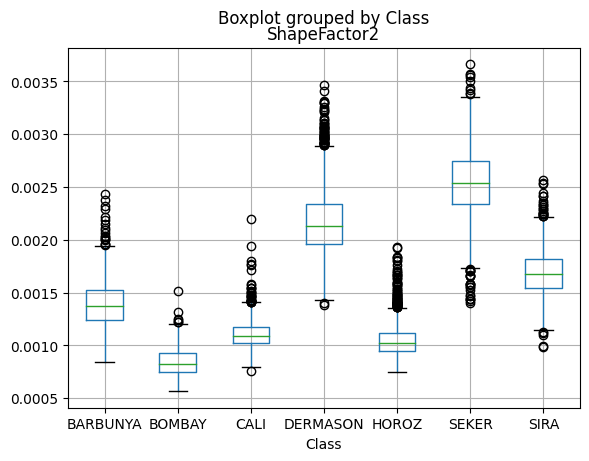

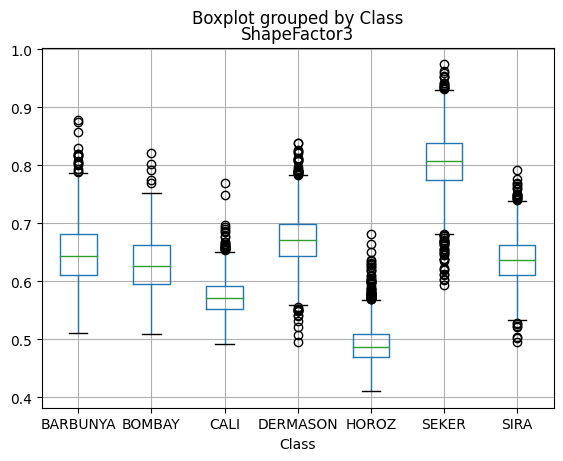

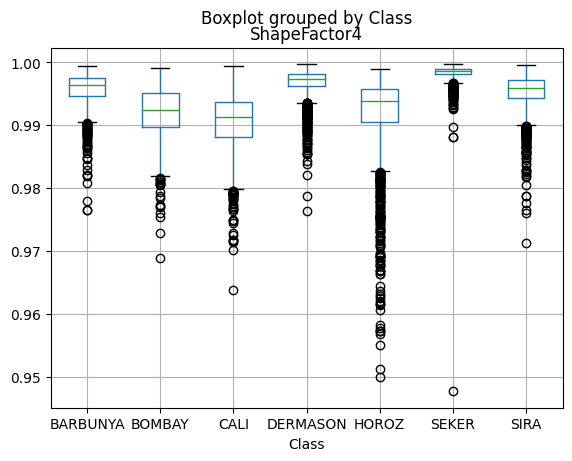

In [110]:
features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
            'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
            'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
            'ShapeFactor3', 'ShapeFactor4']

label = ['Class']
labelnames= ['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira']

for col in features:
    bean.boxplot(column = col, by = 'Class')
mp.show()

The Bombay class is noticably different from the other classes and therefore we can consider this data to be fit for our classification model.

---

#### Data Separation

We should split our test and train data in ratio 1:4.

In [111]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25)

print ('Training Set: %d rows\nTest Set: %d rows' % (x_train.shape[0], x_test.shape[0]))

Training Set: 10208 rows
Test Set: 3403 rows


#### Training and evaluating a classifier

We're all set to train and evaluate a muti-class classifier.

In [112]:
from sklearn.linear_model import LogisticRegression
# regularization parameter
reg = 0.01

# train a logistic regression model on the training set with the specified regularization parameter
multi_model = LogisticRegression(C=1/reg, solver='lbfgs', multi_class='auto', max_iter=10000).fit(x_train,y_train)
print(multi_model)

LogisticRegression(C=100.0, max_iter=10000)


C:\Users\chitr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Our model is trained, so its the of evaluating-

In [113]:
# Evaluate the predictions on the test set
res = multi_model.predict(x_test)

# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test,res))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,res)
print(cm)


              precision    recall  f1-score   support

           0       0.94      0.95      0.95       532
           1       0.92      0.87      0.89       314
           2       1.00      1.00      1.00       108
           3       0.93      0.92      0.92       447
           4       0.92      0.95      0.94       477
           5       0.84      0.84      0.84       631
           6       0.91      0.91      0.91       894

    accuracy                           0.91      3403
   macro avg       0.92      0.92      0.92      3403
weighted avg       0.91      0.91      0.91      3403

[[506   3   0   0   0  15   8]
 [  5 272   0  25   2  10   0]
 [  0   0 108   0   0   0   0]
 [  0  17   0 411  14   5   0]
 [  0   2   0   7 454  11   3]
 [  9   1   0   1  21 533  66]
 [ 16   1   0   0   0  60 817]]


The classification report displays *macro avg* and *weighted avg* instead of accuracy and precision because in binary classification we could see only positive rates, but in multi-class, we need to see an overall score(either weighted or macro) to see how our model performs on our data.

---

The confusion matrix we created is very difficult to understand, so we can create a ***Heat Map*** to visualise the matrix.

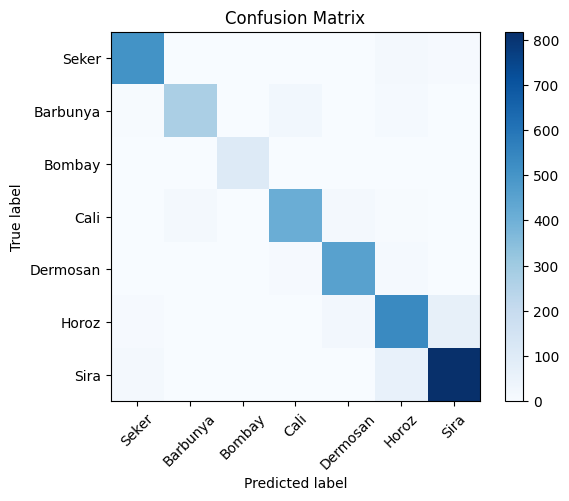

In [114]:
import numpy as np
import matplotlib.pyplot as mp

mp.imshow(cm, interpolation='nearest', cmap=mp.cm.Blues)
mp.colorbar()
classNames = ['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira']
mp.title('Confusion Matrix')
mp.ylabel('True label')
mp.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
mp.xticks(tick_marks, classNames, rotation=45)
mp.yticks(tick_marks, classNames)
mp.show()

Here, we can clearly see that model is having a hard time in predicting the *Bombay* class as it is considerably differentiated from the other class. We can plot an ROC curve to see what is the status, however, the ROC curve we used in binary classification cannot be used here. So, we'll plot an ROC curve based on **One vs Rest(OVR)** approach as,

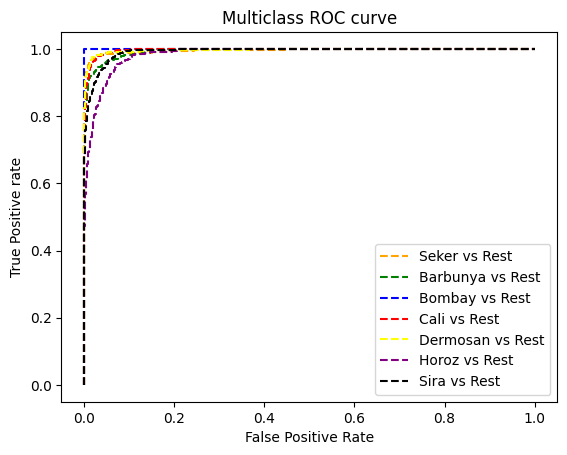

In [115]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as mp

prob = multi_model.predict_proba(x_test)
auc = roc_auc_score(y_test, prob, multi_class='ovr')
fpr = {}
tpr = {}
thresh ={}
n_class = 7
for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test, prob[:,i], pos_label=i)

mp.plot(fpr[0], tpr[0], linestyle='--',color='orange', label='Seker vs Rest')
mp.plot(fpr[1], tpr[1], linestyle='--',color='green', label='Barbunya vs Rest')
mp.plot(fpr[2], tpr[2], linestyle='--',color='blue', label='Bombay vs Rest')
mp.plot(fpr[3], tpr[3], linestyle='--',color='red', label='Cali vs Rest')
mp.plot(fpr[4], tpr[4], linestyle='--',color='yellow', label='Dermosan vs Rest')
mp.plot(fpr[5], tpr[5], linestyle='--',color='purple', label='Horoz vs Rest')
mp.plot(fpr[6], tpr[6], linestyle='--',color='black', label='Sira vs Rest')
mp.title('Multiclass ROC curve')
mp.xlabel('False Positive Rate')
mp.ylabel('True Positive rate')
mp.legend(loc='best')
mp.show()

we can calculate the AUC score of this curve by-

In [116]:
auc = roc_auc_score(y_test, prob, multi_class='ovr')
print('AUC: ', auc)

AUC:  0.9939730726357546


#### Pipeline Preprocessing

The unprocessed data often leads to problems. We should always preprocess our data in a pipeline before creating a model out of it.

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC

# Define preprocessing for numeric columns (scale them)
numeric_features = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)])

# Create preprocessing and training pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', LogisticRegression(C=1/reg, solver='lbfgs', multi_class='auto', max_iter=10000))]) # We used LogisticRegression here, you can use any other regressor

# fit the pipeline to train a linear regression model on the training set
model_pre = pipeline.fit(x_train, y_train)
print (model_pre)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14])])),
                ('regressor', LogisticRegression(C=100.0, max_iter=10000))])


Time for evaluation

Accuracy:  0.9235968263297091
Precision:  0.9237850555032987
Recall:  0.9235968263297091
AUC:  0.995395883870762


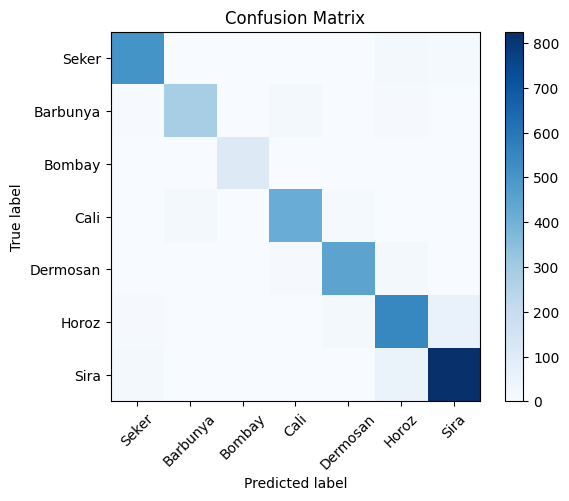

In [118]:
res = model_pre.predict(x_test)
prob = model_pre.predict_proba(x_test)

# Overall Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score

print("Accuracy: ",accuracy_score(y_test,res))
print("Precision: ",precision_score(y_test,res,average='weighted'))
print("Recall: ",recall_score(y_test,res,average='weighted'))
print("AUC: ",roc_auc_score(y_test,prob,multi_class='ovr'))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,res)
mp.imshow(cm, interpolation='nearest', cmap=mp.cm.Blues)
mp.colorbar()
classNames = ['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira']
mp.title('Confusion Matrix')
mp.ylabel('True label')
mp.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
mp.xticks(tick_marks, classNames, rotation=45)
mp.yticks(tick_marks, classNames)
mp.show()


#### Comparison

Its time to see which model worked best on our data-

| Model | AUC Score |
| :------: | :------: |
| Unprocessed |  0.9926002718150858 |
| Preprocessed | 0.9943454521742433 |

There is a little difference in preprocessed and unprocessed models. But it does not conclude that preprocessing doesn't helps. I just included AUC score, might be that preprocessing enhanced other metrics except this one. So, you should always experiment with your data and see which technique fits you the best.


#### Inferencing

We should save our model using the joblib library.

In [119]:
import joblib as jb

jb.dump(model_pre,'d:/Projects/ML/assets/bean-model.pkl')

['d:/Projects/ML/assets/bean-model.pkl']

Let's use this model on a new sample-

In [120]:
import joblib as jb
import numpy as np

# Load the model
model = jb.load('d:/Projects/ML/assets/bean-model.pkl')

# Define the new sample
new_sample = np.array([[15.26, 14.84, 0.871, 5.763, 3.312, 2.221, 5.22, 1.0, 0.871, 6.0, 202.0, 0.306, 0.002, 0.002, 0.527, 1.0]])

# Predict the class of the new sample
prediction = model.predict(new_sample)

if prediction[0] == 0:
    print('Predicted class: Seker')
elif prediction[0] == 1:
    print('Predicted class: Barbunya')
elif prediction[0] == 2:
    print('Predicted class: Bombay')
elif prediction[0] == 3:
    print('Predicted class: Cali')
elif prediction[0] == 4:
    print('Predicted class: Dermosan')
elif prediction[0] == 5:
    print('Predicted class: Horoz')
elif prediction[0] == 6:
    print('Predicted class: Sira')
else:
    print('Error')


Predicted class: Bombay


C:\Users\chitr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<center>Congratulations🎊<br>
You've successfully completed Classification</center>

---

## Clustering

Clustering comes under *unsupervised machine learning* where there is no label present in the provided dataset. Let's get started by importing [stock price dataset](https://archive.ics.uci.edu/dataset/585/stock+keeping+units) from UCI.

In [121]:
import pandas as pd
import matplotlib.pyplot as mp

df = pd.read_excel('d:/Projects/ML/assets/sku_data.xlsx')
feature = df[df[1:].columns[1:]]
feature.head()

,Unitprice,Expire date,Outbound number,Total outbound,Pal grossweight,Pal height,Units per pal
0,0.058,547,9,2441.0,105.60,1.56,1920
1,0.954,547,0,0.0,207.68,1.00,384
2,2.385,547,12,23.0,165.78,1.02,108
3,5.100,547,0,0.0,221.04,1.05,72
4,0.000,547,0,0.0,0.00,0.00,0


As it can be seen from the dataset, there is no column having any corresponding class for any of the instance, so we'll have to cluster them based on their similarities. We can represent each of these values as coordinates and then we can find similarity(or distance) between those coordinates to create a clustering model. But it is difficult to visualise 7-dimensions in a 3D world and almost impossible to plot on a 2D graph. That's where ***Principal Component Analysis*** method from mathematics kicks in, it'll translate these 7D coords into our 2D graphs.

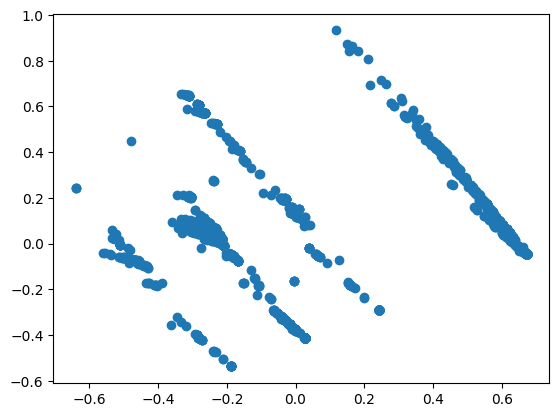

In [122]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as mp

sf = MinMaxScaler().fit_transform(feature)
pca = PCA(n_components=2).fit(sf)
d2 = pca.transform(sf)
mp.scatter(d2[:,0],d2[:,1])
mp.show()

This dataset seems pretty easy, we can easily create 4 clusters for this dataset. But, how?

One way is to create a series of clustering models with incrementing number of clusters and measure how tightly the data is grouped together. We use a metric called ***Within Cluster Sum of Squares***. The lower the WCSS, the more closely the data is packed.

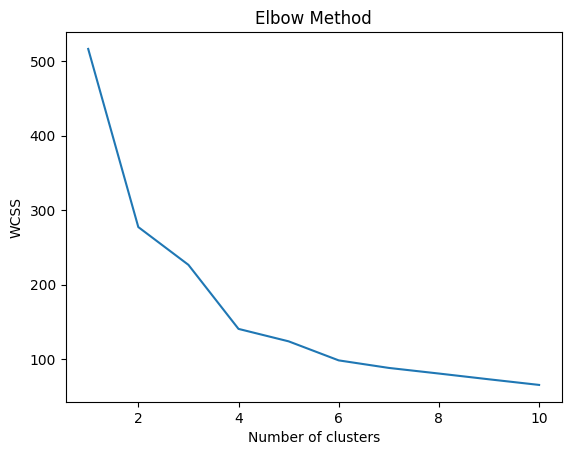

In [123]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as mp

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++',random_state=42)
    kmeans.fit(sf)
    wcss.append(kmeans.inertia_)
mp.plot(range(1,11),wcss)
mp.title('Elbow Method')
mp.xlabel('Number of clusters')
mp.ylabel('WCSS')
mp.show()

### K-Means Clustering

In previous code block, we used K-Means clustering algorithm which is a very common algorithm. It separates out K clusters of same variance. It proceeds through these steps - 

1. A set of K centroids are randomly chosen.
2. Clusters are formed by assigning the data points to their closest centroid.
3. The means of each cluster is computed and the centroid is moved to the mean.
4. Steps 2 and 3 are repeated until a stopping criteria is met. Typically, the algorithm terminates when each new iteration results in negligable movement of centroids and the clusters become static.
5. When the clusters stop changing, the algorithm has *converged*, defining the locations of the clusters - note that the random starting point for the centroids means that re-running the algorithm could result in slightly different clusters, so training usually involves multiple iterations, reinitializing the centroids each time, and the model with the best WCSS is selected.

We'll use a k-value of 4 in our dataset.

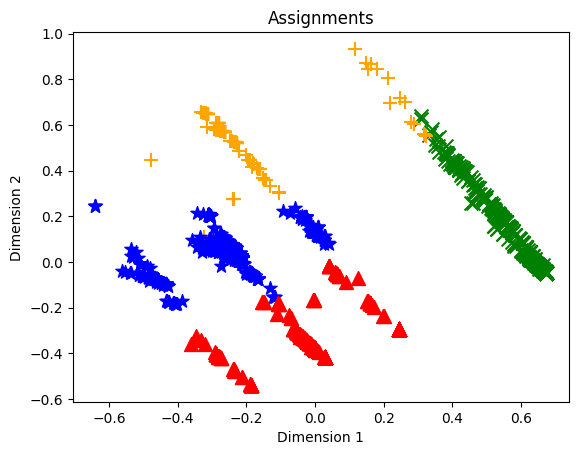

In [124]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, init='k-means++',random_state=42)
clusters = kmeans.fit_predict(sf)
col_dic = {0:'blue',1:'green',2:'orange',3:'red'}
mrk_dic = {0:'*',1:'x',2:'+',3:'^'}
colors = [col_dic[x] for x in clusters]
markers = [mrk_dic[x] for x in clusters]
for sample in range(len(clusters)):
    mp.scatter(d2[sample][0], d2[sample][1], color = colors[sample], marker=markers[sample], s=100)
mp.xlabel('Dimension 1')
mp.ylabel('Dimension 2')
mp.title('Assignments')
mp.show()


### Hierarchial Clustering

This type of clustering makes fewer assumptions compared to K-means. It creates models on either of **agglomertative** or **divisive** type of clustering where agglomerative is a **bottom-up** appproach and divisive is a **top-down** approach.

Here, we'll use agglomerative clustering which works as-

>1. The linkage distances between each of the data points is computed.
>2. Points are clustered pairwise with their nearest neighbor.
>3. Linkage distances between the clusters are computed.
>4. Clusters are combined pairwise into larger clusters.
>5. Steps 3 and 4 are repeated until all data points are in a single cluster.

>The linkage function can be computed in a number of ways:
- Ward linkage measures the increase in variance for the clusters being linked,
- Average linkage uses the mean pairwise distance between the members of the two clusters,
- Complete or Maximal linkage uses the maximum distance between the members of the two clusters.

>Several different distance metrics are used to compute linkage functions:
- Euclidian or l2 distance is the most widely used. This is the only metric for the Ward linkage method.
- Manhattan or l1 distance is robust to outliers and has other interesting properties.
- Cosine similarity, is the dot product between the location vectors divided by the magnitudes of the vectors. Notice that this metric is a measure of similarity, whereas the other two metrics are measures of difference. Similarity can be quite useful when working with data such as images or text documents.


In [125]:
from sklearn.cluster import AgglomerativeClustering

# Create the agglomerative clustering model
model = AgglomerativeClustering(n_clusters=4)

# Fit the model to the data
clusters = model.fit_predict(feature)

Let's see how our model has clustered our data-

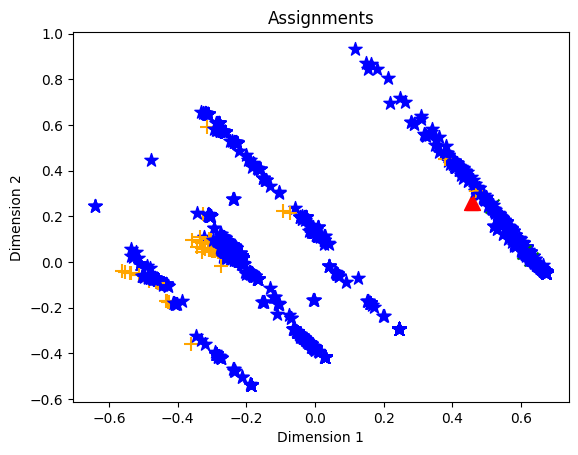

In [126]:
import matplotlib.pyplot as mp

col_dic = {0:'blue',1:'green',2:'orange',3:'red'}
mrk_dic = {0:'*',1:'x',2:'+',3:'^'}
colors = [col_dic[x] for x in clusters]
markers = [mrk_dic[x] for x in clusters]
for sample in range(len(clusters)):
    mp.scatter(d2[sample][0], d2[sample][1], color = colors[sample], marker=markers[sample], s=100)
mp.xlabel('Dimension 1')
mp.ylabel('Dimension 2')
mp.title('Assignments')
mp.show()

<center>🍾YooHoo!🍾<br>You Completed Clustering</center>

---

This marks the end of our journey of Machine Learning. Hope you like it.

<center>***🫡 Signing off 🫡***</center>